# 🔬 Exploración de la Base Agrícola Valle del Cauca 2019-2025 (v3)

**Objetivo:** caracterizar el dataset fuente (filtrado a Valle del Cauca) para diseñar el modelo predictivo v3, con análisis separados a nivel **anual** y **semestral**.

**v3 incorpora, sobre v2:**
- Detección de fila de encabezado real (fila 8; las filas 0-7 son metadata del reporte EVA-UPRA).
- Filtro explícito a `Departamento == 'Valle del Cauca'` (el archivo trae los 32 departamentos).
- `detectar_columna()` corregida: prioriza coincidencia **exacta** antes que substring (evitaba que `'Código Dane municipio'` ganara sobre `'Municipio'`).
- Separación de la columna `Periodo` en año + semestre (A/B), detectando que el archivo mezcla dos granularidades: cultivos permanentes reportados solo anual, cultivos transitorios reportados semestral.
- Limpieza de 2 combinaciones (muni×cultivo×año) donde coexistían fila anual plana Y filas A/B con valores inconsistentes entre sí — se conserva el semestral (A+B) como fuente de verdad y se descarta el agregado plano, documentando la discrepancia.
- Dos ramas de análisis independientes desde el Paso 5: **ANUAL** (todo el portafolio, 78 cultivos) y **SEMESTRAL** (solo ciclo corto/transitorios, ~39 cultivos).

In [1]:
# ===== Celda 0: imports, configuración y helpers =====
from pathlib import Path
import unicodedata
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

def normalizar(s):
    """Minúsculas y sin tildes: 'Producción (t)' -> 'produccion (t)'."""
    s = str(s)
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn').lower()

def detectar_columna(df, *patrones, obligatorio=True):
    """Detecta una columna por nombre normalizado.

    Prioriza COINCIDENCIA EXACTA (evita que 'Código Dane municipio' gane
    sobre 'Municipio' solo porque contiene la subcadena). Si ningún patrón
    matchea exacto, cae a substring como respaldo. Los patrones se prueban
    en orden de prioridad.
    """
    cols_norm = {c: normalizar(c) for c in df.columns}

    for p in patrones:
        exactas = [c for c, cn in cols_norm.items() if cn == p]
        if exactas:
            return exactas[0]

    for p in patrones:
        candidatas = [c for c, cn in cols_norm.items() if p in cn]
        if candidatas:
            return candidatas[0]

    if obligatorio:
        raise ValueError(f"No se encontro columna para patrones {patrones}. "
                         f"Columnas disponibles: {list(df.columns)}")
    return None

# --- Configuración ---
RUTA_XLSX = Path(r"C:\Users\Usuario\Downloads\20260526_BaseAgricola20192025 (1).xlsx")
FILA_ENCABEZADO = 8          # filas 0-7 son metadata del reporte (título, fuente, etc.)
DEPARTAMENTO_OBJETIVO = 'Valle del Cauca'
ANOS_CHOQUE = [2020, 2021]   # ventana de choque COVID, para anotaciones y filtros

print(f"Archivo: {RUTA_XLSX}")
print(f"Existe: {RUTA_XLSX.exists()}")
if RUTA_XLSX.exists():
    print(f"Tamaño: {RUTA_XLSX.stat().st_size / 1024 / 1024:.1f} MB")

Archivo: C:\Users\Usuario\Downloads\20260526_BaseAgricola20192025 (1).xlsx
Existe: True
Tamaño: 25.1 MB


## Paso 1 — ¿Qué contiene el XLSX?

**Salida esperada:** nombres de hojas y previsualización cruda (sin asumir encabezado) para ubicar dónde empieza la tabla real.

In [2]:
# ===== Celda 1: inspección de hojas (cruda, sin asumir encabezado) =====
xls = pd.ExcelFile(RUTA_XLSX)
HOJA_PRINCIPAL = xls.sheet_names[0]

print(f"Número de hojas: {len(xls.sheet_names)}")
for i, nombre in enumerate(xls.sheet_names, 1):
    print(f"  {i}. {nombre}")

print("\n" + "="*80)
print(f"Primeras {FILA_ENCABEZADO + 3} filas de la hoja principal ({HOJA_PRINCIPAL}), header=None:")
print("="*80)
raw = pd.read_excel(RUTA_XLSX, sheet_name=HOJA_PRINCIPAL, header=None, nrows=FILA_ENCABEZADO + 3)
display(raw)

Número de hojas: 2
  1. BasePagina
  2. BaseSIPRA

Primeras 11 filas de la hoja principal (BasePagina), header=None:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EVALUACIONES AGROPECUARIAS MUNICIPALES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BASE AGRÍCOLA 2019 - 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Fuente: EVA -UPRA, con base en información de:...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"* Los datos de área cosechada, producción y re...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,* Las cifras de los dos últimos años son susce...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"* El municipio Nuevo Belén de Bajirá, código 2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,* Se ajustaron las cifras de producción y rend...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Desagregación cultivo,Cultivo,Ciclo del cultivo,Grupo cultivo,Subgrupo,Año,Periodo,Área sembrada (ha),Área cosechada (ha),Producción (t),Rendimiento (t/ha),Nombre científico del cultivo,Código del cultivo,Estado físico del cultivo
9,05,Antioquia,05001,Medellín,Apio,Apio,Transitorio,Hortalizas,Hortalizas de tallo,2021,2021A,8,8,128,16,Apium graveolens,1050600,En fresco


## Paso 2 — Carga de la hoja principal + filtro a Valle del Cauca

**Criterio:** el encabezado real está en `FILA_ENCABEZADO` (confirmado en el Paso 1). El archivo trae los 32 departamentos de Colombia; se filtra explícitamente al departamento objetivo.

In [3]:
# ===== Celda 2: carga principal + filtro departamental =====
df = pd.read_excel(RUTA_XLSX, sheet_name=HOJA_PRINCIPAL, header=FILA_ENCABEZADO)
df = df.dropna(axis=1, how='all')
df.columns = [str(c).strip() for c in df.columns]

print(f"Shape original: {df.shape}")
print(f"\nDepartamentos presentes en el archivo:")
print(df['Departamento'].value_counts())

mask_valle = df['Departamento'].map(normalizar).str.strip() == normalizar(DEPARTAMENTO_OBJETIVO)
df = df[mask_valle].copy()

print(f"\nShape tras filtrar {DEPARTAMENTO_OBJETIVO}: {df.shape}")
print(f"Municipios encontrados ({df['Municipio'].nunique()}):")
print(sorted(df['Municipio'].unique()))

Shape original: (166733, 18)

Departamentos presentes en el archivo:
Departamento
Boyacá                                                      17679
Cundinamarca                                                15585
Antioquia                                                   15216
Santander                                                   13071
Huila                                                       11769
Nariño                                                      11568
Valle del Cauca                                             10589
Cauca                                                        7518
Norte de Santander                                           7125
Tolima                                                       6688
Bolívar                                                      4834
Magdalena                                                    4295
Cesar                                                        4268
Meta                                                        

## Paso 3 — Inventario de columnas

In [4]:
# ===== Celda 3: inventario =====
for col in df.columns:
    nulos = df[col].isna().sum()
    print(f"\n📋 {col!r}  |  tipo: {df[col].dtype}  |  únicos: {df[col].nunique():,}  |  nulos: {nulos:,}")
    muestra = df[col].dropna().iloc[:3].tolist()
    print(f"   muestra: {muestra}")
    if df[col].dtype in ['int64', 'float64']:
        print(f"   rango: {df[col].min():,.2f} → {df[col].max():,.2f} | media: {df[col].mean():,.2f}")


📋 'Código Dane departamento'  |  tipo: int64  |  únicos: 1  |  nulos: 0
   muestra: [76, 76, 76]
   rango: 76.00 → 76.00 | media: 76.00

📋 'Departamento'  |  tipo: str  |  únicos: 1  |  nulos: 0
   muestra: ['Valle del Cauca', 'Valle del Cauca', 'Valle del Cauca']

📋 'Código Dane municipio'  |  tipo: int64  |  únicos: 42  |  nulos: 0
   muestra: [76001, 76001, 76001]
   rango: 76,001.00 → 76,895.00 | media: 76,436.27

📋 'Municipio'  |  tipo: str  |  únicos: 42  |  nulos: 0
   muestra: ['Santiago de Cali', 'Santiago de Cali', 'Santiago de Cali']

📋 'Desagregación cultivo'  |  tipo: str  |  únicos: 97  |  nulos: 0
   muestra: ['Acelga', 'Acelga', 'Acelga']

📋 'Cultivo'  |  tipo: str  |  únicos: 78  |  nulos: 0
   muestra: ['Acelga', 'Acelga', 'Acelga']

📋 'Ciclo del cultivo'  |  tipo: str  |  únicos: 2  |  nulos: 0
   muestra: ['Transitorio', 'Transitorio', 'Transitorio']

📋 'Grupo cultivo'  |  tipo: str  |  únicos: 8  |  nulos: 0
   muestra: ['Hortalizas', 'Hortalizas', 'Hortalizas']



## Paso 4 — Detección de claves y descomposición temporal (año / semestre)

`Periodo` mezcla dos formatos: `'2021'` (anual plano) y `'2021A'` / `'2021B'` (semestral). Se extrae el semestre cuando existe; las filas sin letra quedan marcadas como `tipo_periodo = 'anual'`.

In [5]:
# ===== Celda 4: claves + descomposición temporal =====
col_ano  = detectar_columna(df, 'ano', 'anio', 'periodo', 'year')
col_muni = detectar_columna(df, 'municipio', 'munic')
col_cult = detectar_columna(df, 'cultivo', 'especie')
col_per  = detectar_columna(df, 'periodo', obligatorio=False)
col_prod = detectar_columna(df, 'produccion ton', 'produccion_t', 'produccion (t',
                            'produccion', 'toneladas')

df[col_ano] = pd.to_numeric(df[col_ano], errors='coerce')
n_sin_ano = df[col_ano].isna().sum()
if n_sin_ano:
    print(f"⚠️ {n_sin_ano} filas sin año convertible; se excluyen")
    df = df.dropna(subset=[col_ano])
df[col_ano] = df[col_ano].astype(int)

df['semestre'] = df[col_per].astype(str).str.extract(r'([AB])$')
df['tipo_periodo'] = np.where(df['semestre'].isna(), 'anual', 'semestral')

print(f"Claves: año={col_ano!r} | municipio={col_muni!r} | cultivo={col_cult!r} "
      f"| periodo={col_per!r} | producción={col_prod!r}")
print(f"\n📅 Años: {sorted(df[col_ano].unique())}")
print(f"🏘️ Municipios: {df[col_muni].nunique()}")
print(f"🌾 Cultivos: {df[col_cult].nunique()}")
print(f"\nValores de {col_per}: {sorted(df[col_per].dropna().unique())}")
print(f"Tipo de periodo: {df['tipo_periodo'].value_counts().to_dict()}")

Claves: año='Año' | municipio='Municipio' | cultivo='Cultivo' | periodo='Periodo' | producción='Producción (t)'

📅 Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
🏘️ Municipios: 42
🌾 Cultivos: 78

Valores de Periodo: ['2019', '2019A', '2019B', '2020', '2020A', '2020B', '2021', '2021A', '2021B', '2022', '2022A', '2022B', '2023', '2023A', '2023B', '2024', '2024A', '2024B', '2025', '2025A', '2025B']
Tipo de periodo: {'semestral': 5908, 'anual': 4681}


## Paso 4b — Limpieza de inconsistencias anual vs. semestral

**Hallazgo:** 2 combinaciones (muni×cultivo×año) tienen simultáneamente fila anual plana Y filas A/B, **con valores que no cuadran entre sí** (no es un simple duplicado):

| Combinación | Anual reportado | Semestral (A+B) | Diferencia |
|---|---|---|---|
| Guacarí / Plantas aromáticas / 2020 | 0.00 t | 85.00 t | 85.00 t |
| La Cumbre / Plantas aromáticas / 2025 | 29.00 t | 36.00 t | 7.00 t (24%) |

**Decisión:** se conserva el dato semestral (A+B) como fuente de verdad — es la observación más granular y directa — y se descarta la fila anual plana en estos 2 casos. Impacto marginal a nivel departamental (2 de 1,182 series, cultivo de bajo volumen), pero se documenta explícitamente como limitación de calidad de datos de la fuente EVA-UPRA.

In [6]:
# ===== Celda 4b: detectar y limpiar combinaciones con ambos formatos =====
mezcla = (df.groupby([col_muni, col_cult, col_ano])['tipo_periodo']
            .nunique().reset_index(name='n_tipos'))
casos_mezclados = mezcla[mezcla['n_tipos'] > 1]
print(f"Combinaciones muni×cultivo×año con AMBOS formatos: {len(casos_mezclados)}")
display(casos_mezclados)

if len(casos_mezclados) > 0:
    idx_a_eliminar = df[
        df.set_index([col_muni, col_cult, col_ano]).index.isin(
            casos_mezclados.set_index([col_muni, col_cult, col_ano]).index
        ) & df['semestre'].isna()
    ].index
    print(f"\nFilas anuales planas eliminadas (se conserva semestral A+B): {len(idx_a_eliminar)}")
    df = df.drop(index=idx_a_eliminar)
    df['tipo_periodo'] = np.where(df['semestre'].isna(), 'anual', 'semestral')

print(f"\nShape final tras limpieza: {df.shape}")

Combinaciones muni×cultivo×año con AMBOS formatos: 2


,Municipio,Cultivo,Año,n_tipos
2751,Guacarí,Plantas aromáticas,2020,2
3347,La Cumbre,Plantas aromáticas,2025,2



Filas anuales planas eliminadas (se conserva semestral A+B): 2

Shape final tras limpieza: (10587, 20)


## Paso 5A — Longitudes de serie: nivel ANUAL

Cubre **todo el portafolio** de cultivos (permanentes + transitorios). Es la base del panel pooled principal para v3.

Series totales (ANUAL): 1,182

Distribución de longitudes (años):
   1 años:    53 series (  4.5%)
   2 años:    83 series (  7.0%)
   3 años:    23 series (  1.9%)
   4 años:    16 series (  1.4%)
   5 años:   120 series ( 10.2%)
   6 años:    93 series (  7.9%)
   7 años:   794 series ( 67.2%)

Top 15 series por producción acumulada:


Municipio            Cultivo
Palmira              Caña      32,660,389.00
Candelaria           Caña      20,830,414.00
El Cerrito           Caña      14,250,600.00
Guacarí              Caña      11,920,388.00
Zarzal               Caña       9,867,793.00
Florida              Caña       9,624,851.00
Bugalagrande         Caña       9,447,376.00
Pradera              Caña       8,439,294.00
Jamundí              Caña       6,761,610.00
Obando               Caña       6,707,526.00
Guadalajara de Buga  Caña       6,646,300.00
Tuluá                Caña       5,484,737.00
Cartago              Caña       4,231,129.00
San Pedro            Caña       3,932,314.00
Andalucía            Caña       3,322,231.00
Name: Producción (t), dtype: float64

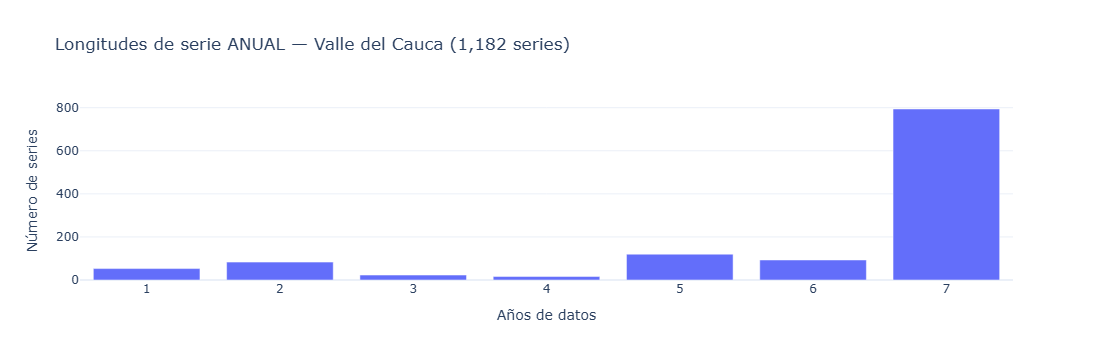

In [7]:
# ===== Celda 5A: longitudes de serie — nivel ANUAL =====
df_anual = (df.groupby([col_muni, col_cult, col_ano])[col_prod]
              .sum().reset_index())

g_anual = df_anual.groupby([col_muni, col_cult])[col_ano].nunique().rename('n_anos')
print(f"Series totales (ANUAL): {len(g_anual):,}")

dist_anual = g_anual.value_counts().sort_index()
print("\nDistribución de longitudes (años):")
for n, count in dist_anual.items():
    print(f"   {n} años: {count:5,} series ({count/len(g_anual)*100:5.1f}%)")

print("\nTop 15 series por producción acumulada:")
display(df_anual.groupby([col_muni, col_cult])[col_prod].sum()
                 .sort_values(ascending=False).head(15).round(0))

fig = px.bar(x=dist_anual.index.astype(str), y=dist_anual.values,
             title=f"Longitudes de serie ANUAL — Valle del Cauca ({len(g_anual):,} series)",
             labels={'x': 'Años de datos', 'y': 'Número de series'})
fig.update_layout(template='plotly_white')
fig.show()

## Paso 5B — Longitudes de serie: nivel SEMESTRAL

**Cobertura parcial por diseño:** solo cultivos que la fuente reporta con desagregación A/B (mayormente transitorios/ciclo corto). Los cultivos permanentes de mayor volumen (caña, café, aguacate, cítricos, plátano, banano, etc.) **no** tienen dato semestral y quedan fuera de esta rama.

### ⚠️ Corrección de integridad: `Cultivo` no es la granularidad real de los datos

**Hallazgo (detectado al construir la regresión laggeada, Paso 18):** `Cultivo` (78 valores) es más grueso que `Desagregación cultivo` (97 valores) — ej. `Maíz` agrupa tanto `Maíz amarillo tradicional` como `Maíz blanco tradicional` como filas separadas para el mismo municipio y periodo. Esto significa que, sin agregar, una combinación (municipio, cultivo, periodo) puede tener **más de una fila** — se encontraron 560 de 5,090 combinaciones así en la rama semestral.

**Por qué esto es grave:** el generador de folds (Paso 14 original) agrupaba por `[municipio, cultivo]` y tomaba las filas ordenadas por periodo como una secuencia — con filas duplicadas del mismo periodo (ej. dos filas distintas ambas etiquetadas `2021B`), la serie quedaba fragmentada en más "puntos temporales" de los que realmente existen, corrompiendo silenciosamente esa serie completa. La rama **anual** nunca tuvo este problema porque `df_anual` (Paso 5A) siempre se construyó con `groupby(...).sum()`, que ya colapsaba cualquier duplicado de Desagregación automáticamente.

**Corrección:** se reconstruye `df_semestral` agregando explícitamente por (municipio, cultivo, periodo) — sumando producción y área, y recalculando rendimiento como producción/área (misma convención ya usada y validada para la rama anual en el Paso 17).

Filas semestrales ANTES de agregar (nivel Desagregación): 5,908
Filas semestrales DESPUÉS de agregar (nivel Cultivo, correcto): 5,090
Combinaciones (muni,cultivo,periodo) que tenían >1 fila (colapsadas ahora): 818

Combinaciones muni×cultivo con dato semestral: 471 de 1,182 totales

⚠️ Cultivos EXCLUIDOS del análisis semestral (solo reportan anual, 40):
['Aguacate', 'Arazá', 'Banano', 'Borojó', 'Brevo', 'Cacao', 'Café', 'Caña', 'Chontaduro', 'Coco', 'Curuba', 'Cúrcuma o azafrán', 'Durazno o albaricoque', 'Fresa', 'Granadilla', 'Guanábana', 'Guayaba', 'Gulupa o cholupa', 'Lima', 'Limón', 'Lulo', 'Macadamia', 'Mandarina', 'Mango', 'Maracuyá', 'Mora', 'Naranja', 'Otros cítricos', 'Papaya', 'Pitahaya', 'Piña', 'Plátano', 'Sacha inchi', 'Stevia', 'Sábila', 'Tomate de árbol', 'Té', 'Uchuva', 'Uva', 'Zapote']

Series semestrales totales: 471
   1 periodos:    25 series (  5.3%)
   2 periodos:    22 series (  4.7%)
   3 periodos:    13 series (  2.8%)
   4 periodos:    22 series (  4.7%)
   5 

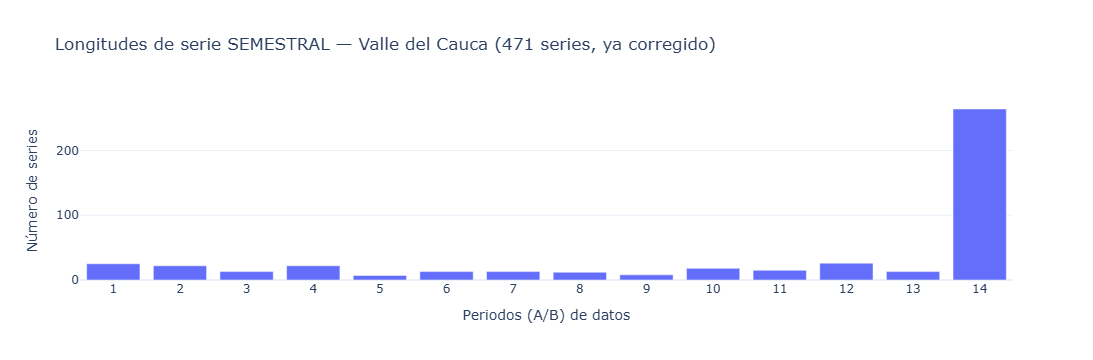


Producción total por semestre (solo cultivos con dato semestral):
semestre
A   1,052,265.02
B   1,014,509.90
Name: Producción (t), dtype: float64


In [8]:
# ===== Celda 5B (corregida): longitudes de serie — nivel SEMESTRAL =====
df_semestral_raw = df[df['tipo_periodo'] == 'semestral'].copy()

# Agregación explícita a la granularidad real de la serie (muni × cultivo × periodo).
# Área y rendimiento se agregan más adelante (Paso 18) cuando se construyen las
# features laggeadas -- aquí solo se necesita producción para longitudes de serie.
df_semestral = (df_semestral_raw
                .groupby([col_muni, col_cult, col_per, col_ano, 'semestre'], as_index=False)[col_prod]
                .sum())

n_combos_originales = df_semestral_raw.groupby([col_muni, col_cult, col_per]).ngroups
n_filas_originales = len(df_semestral_raw)
print(f"Filas semestrales ANTES de agregar (nivel Desagregación): {n_filas_originales:,}")
print(f"Filas semestrales DESPUÉS de agregar (nivel Cultivo, correcto): {len(df_semestral):,}")
print(f"Combinaciones (muni,cultivo,periodo) que tenían >1 fila (colapsadas ahora): "
      f"{n_filas_originales - len(df_semestral):,}")

print(f"\nCombinaciones muni×cultivo con dato semestral: "
      f"{df_semestral.groupby([col_muni, col_cult]).ngroups:,} de "
      f"{df.groupby([col_muni, col_cult]).ngroups:,} totales")

cultivos_solo_anual = sorted(set(df[col_cult].unique()) - set(df_semestral[col_cult].unique()))
print(f"\n⚠️ Cultivos EXCLUIDOS del análisis semestral (solo reportan anual, {len(cultivos_solo_anual)}):")
print(cultivos_solo_anual)

g_sem = df_semestral.groupby([col_muni, col_cult])[col_per].nunique().rename('n_periodos')
print(f"\nSeries semestrales totales: {len(g_sem):,}")
dist_sem = g_sem.value_counts().sort_index()
for n, count in dist_sem.items():
    print(f"   {n} periodos: {count:5,} series ({count/len(g_sem)*100:5.1f}%)")

fig = px.bar(x=dist_sem.index.astype(str), y=dist_sem.values,
             title=f"Longitudes de serie SEMESTRAL — Valle del Cauca ({len(g_sem):,} series, ya corregido)",
             labels={'x': 'Periodos (A/B) de datos', 'y': 'Número de series'})
fig.update_layout(template='plotly_white')
fig.show()

prod_por_semestre = df_semestral.groupby('semestre')[col_prod].sum()
print(f"\nProducción total por semestre (solo cultivos con dato semestral):\n{prod_por_semestre}")

## Paso 6A — Choque 2020-2021: nivel ANUAL (agregado departamental + top cultivos)

,anio,produccion_total,var_pct
0,2019,"24,713,772.33",NaN
1,2020,"24,752,592.68",0.16
2,2021,"25,880,893.10",4.56
3,2022,"25,861,658.62",-0.07
4,2023,"26,731,968.61",3.37
5,2024,"28,153,411.10",5.32
6,2025,"28,552,710.99",1.42


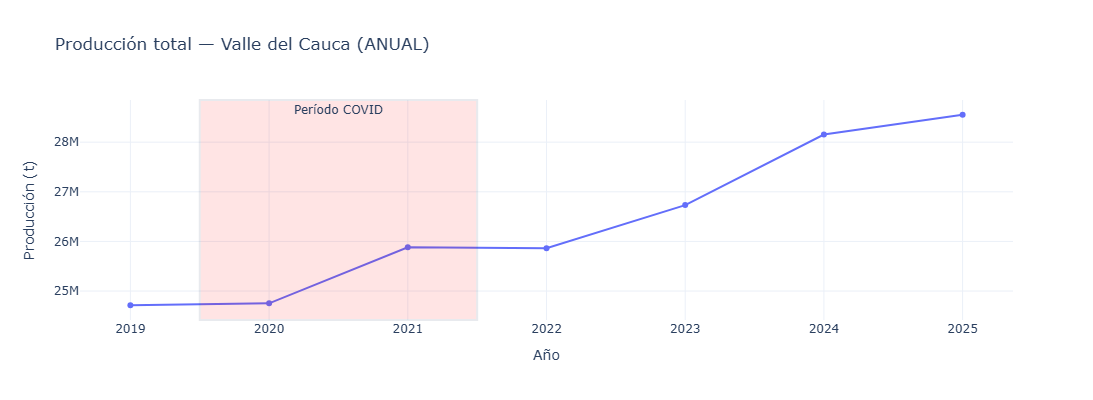

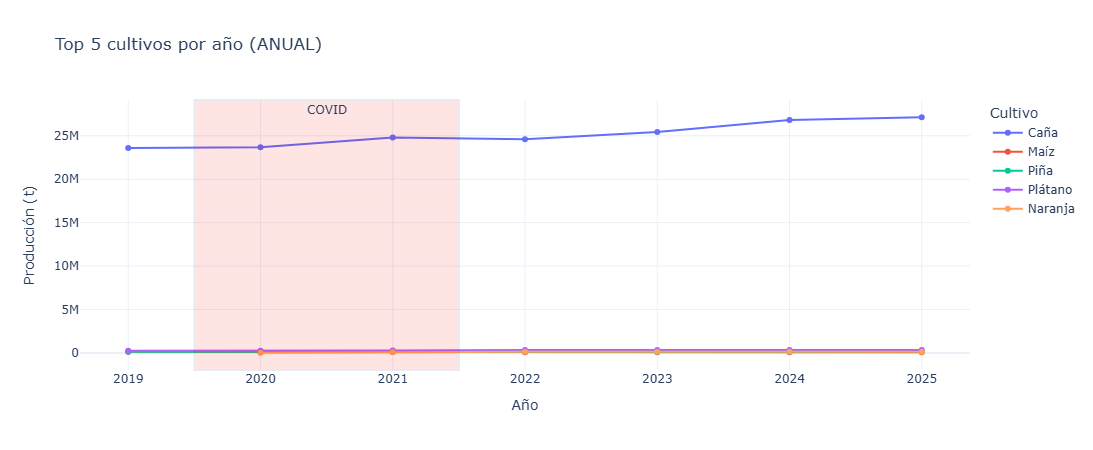

In [9]:
# ===== Celda 6A: choque — ANUAL =====
prod_anual_dpto = (df_anual.groupby(col_ano)[col_prod].sum()
                   .reset_index().rename(columns={col_ano: 'anio', col_prod: 'produccion_total'}))
prod_anual_dpto['var_pct'] = prod_anual_dpto['produccion_total'].pct_change() * 100
display(prod_anual_dpto)

fig = px.line(prod_anual_dpto, x='anio', y='produccion_total', markers=True,
              title='Producción total — Valle del Cauca (ANUAL)',
              labels={'produccion_total': 'Producción (t)', 'anio': 'Año'})
fig.add_vrect(x0=ANOS_CHOQUE[0]-0.5, x1=ANOS_CHOQUE[-1]+0.5, fillcolor='red', opacity=0.1,
              annotation_text='Período COVID', annotation_position='top')
fig.update_layout(template='plotly_white', height=400)
fig.show()

top_cultivos = df_anual.groupby(col_cult)[col_prod].sum().nlargest(5).index
agg_top = (df_anual[df_anual[col_cult].isin(top_cultivos)]
           .groupby([col_ano, col_cult])[col_prod].sum().reset_index())

fig = px.line(agg_top, x=col_ano, y=col_prod, color=col_cult, markers=True,
              title='Top 5 cultivos por año (ANUAL)',
              labels={col_prod: 'Producción (t)'})
fig.add_vrect(x0=ANOS_CHOQUE[0]-0.5, x1=ANOS_CHOQUE[-1]+0.5, fillcolor='red', opacity=0.1,
              annotation_text='COVID', annotation_position='top')
fig.update_layout(template='plotly_white', height=450)
fig.show()

## Paso 6B — Choque 2020-2021: nivel SEMESTRAL

,Año,semestre,Producción (t),etiqueta
0,2019,A,"151,066.80",2019A
1,2019,B,"137,513.15",2019B
2,2020,A,"146,169.93",2020A
3,2020,B,"126,690.55",2020B
4,2021,A,"143,886.29",2021A
5,2021,B,"132,271.73",2021B
6,2022,A,"127,959.01",2022A
7,2022,B,"135,545.94",2022B
8,2023,A,"152,175.24",2023A
9,2023,B,"159,371.66",2023B


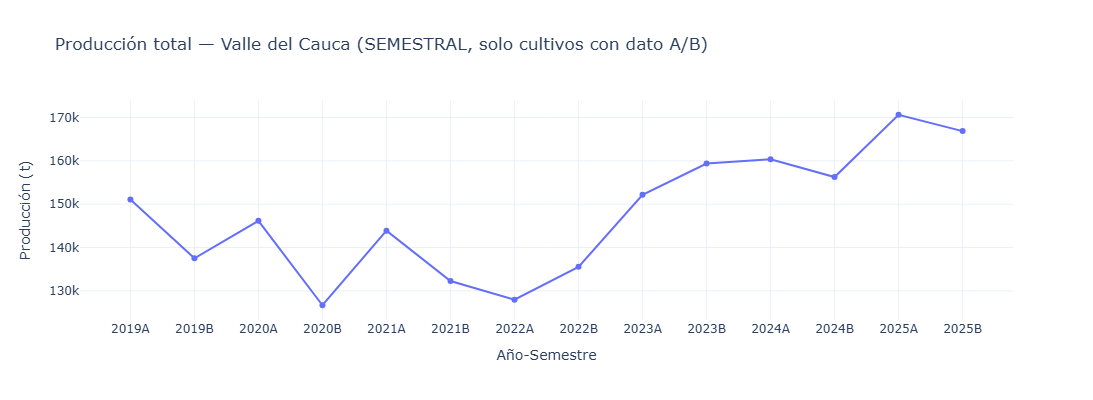


Comparación A vs B por año (¿el choque golpeó un semestre más que otro?):


semestre,A,B
Año,,
2019,"151,066.80","137,513.15"
2020,"146,169.93","126,690.55"
2021,"143,886.29","132,271.73"
2022,"127,959.01","135,545.94"
2023,"152,175.24","159,371.66"
2024,"160,374.59","156,254.61"
2025,"170,633.16","166,862.26"


In [10]:
# ===== Celda 6B: choque — SEMESTRAL =====
prod_sem_dpto = (df_semestral.groupby([col_ano, 'semestre'])[col_prod].sum()
                 .reset_index())
prod_sem_dpto['etiqueta'] = prod_sem_dpto[col_ano].astype(str) + prod_sem_dpto['semestre']
display(prod_sem_dpto)

fig = px.line(prod_sem_dpto, x='etiqueta', y=col_prod, markers=True,
              title='Producción total — Valle del Cauca (SEMESTRAL, solo cultivos con dato A/B)',
              labels={col_prod: 'Producción (t)', 'etiqueta': 'Año-Semestre'})
fig.update_layout(template='plotly_white', height=400)
fig.show()

pivot_sem = prod_sem_dpto.pivot(index=col_ano, columns='semestre', values=col_prod)
print("\nComparación A vs B por año (¿el choque golpeó un semestre más que otro?):")
display(pivot_sem)

## Paso 7 — Consistencia agronómica (área y rendimiento)

Verificar si `rendimiento ≈ producción / área`. Patrones específicos para área sembrada/cosechada; se evita `'ha'` suelto (matchearía 'Fecha', 'Cosecha'...).

área sembrada: 'Área sembrada (ha)' | área cosechada: 'Área cosechada (ha)'
rendimiento:   'Rendimiento (t/ha)' | área usada para el cálculo: 'Área cosechada (ha)'

Filas con área > 0: 10,389 de 10,587

Desviación |rend_calc − rend_reportado| (%):


count   10,389.00
mean         0.02
std          0.10
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          3.23
Name: desv_pct, dtype: float64

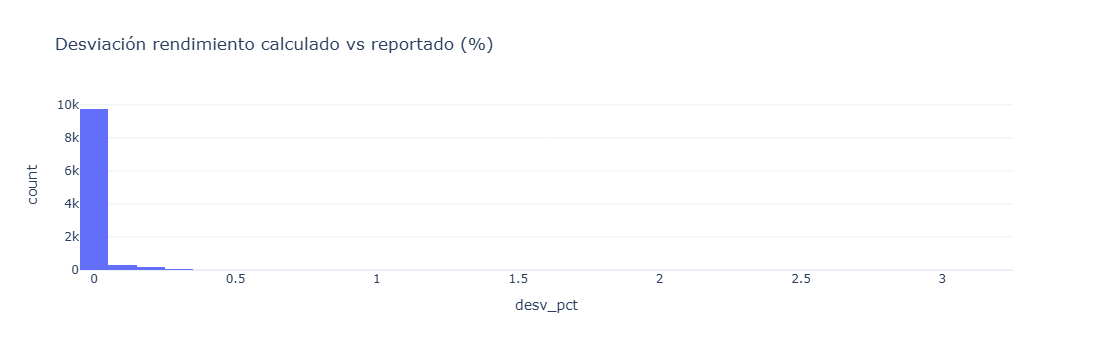


✅ Desviación ~0% → el rendimiento reportado es confiable y puede usarse como feature (siempre LAGGEADO para no fugar información futura).


In [11]:
# ===== Celda 7: consistencia agronómica =====
col_area_sem = detectar_columna(df, 'area sembrada', obligatorio=False)
col_area_cos = detectar_columna(df, 'area cosechada', obligatorio=False)
col_rend     = detectar_columna(df, 'rendimiento', obligatorio=False)
col_area     = col_area_cos or col_area_sem or detectar_columna(df, 'hectarea', 'area', obligatorio=False)

print(f"área sembrada: {col_area_sem!r} | área cosechada: {col_area_cos!r}")
print(f"rendimiento:   {col_rend!r} | área usada para el cálculo: {col_area!r}")

if col_area and col_rend:
    d = df[df[col_area] > 0].copy()
    d['rend_calc'] = d[col_prod] / d[col_area]
    d['desv_pct'] = (d['rend_calc'] - d[col_rend]).abs() / d[col_rend].replace(0, np.nan) * 100
    print(f"\nFilas con área > 0: {len(d):,} de {len(df):,}")
    print("\nDesviación |rend_calc − rend_reportado| (%):")
    display(d['desv_pct'].describe().round(2))
    fig = px.histogram(d, x='desv_pct', nbins=60,
                       title='Desviación rendimiento calculado vs reportado (%)')
    fig.update_layout(template='plotly_white', height=350)
    fig.show()
    print("\n✅ Desviación ~0% → el rendimiento reportado es confiable y puede usarse"
          " como feature (siempre LAGGEADO para no fugar información futura).")
else:
    print("\n⚠️ Sin par área+rendimiento en este archivo.")

## Paso 8 — Caso de estudio: Plátano en Sevilla

Registros: 7 | tipo_periodo: ['anual']


,Año,Periodo,Municipio,Cultivo,Producción (t),Área cosechada (ha),Rendimiento (t/ha)
157846,2019,2019,Sevilla,Plátano,"40,830.00","4,083.00",10.00
157847,2020,2020,Sevilla,Plátano,"30,198.00","4,314.00",7.00
157848,2021,2021,Sevilla,Plátano,"30,100.94","4,294.00",7.01
157849,2022,2022,Sevilla,Plátano,"77,832.00","4,324.00",18.00
157850,2023,2023,Sevilla,Plátano,"77,850.00","4,325.00",18.00
157851,2024,2024,Sevilla,Plátano,"77,796.00","4,322.00",18.00
157852,2025,2025,Sevilla,Plátano,"81,630.00","4,535.00",18.00


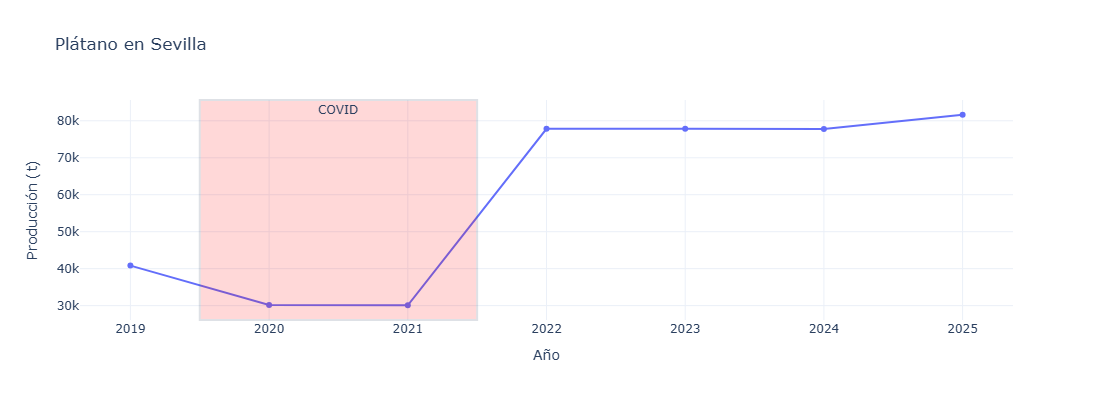

In [12]:
# ===== Celda 8: caso Plátano/Sevilla =====
mask_cult = df[col_cult].map(normalizar).str.contains('platano', na=False)
mask_muni = df[col_muni].map(normalizar).str.contains('sevilla', na=False)
serie = df[mask_cult & mask_muni].sort_values([col_ano, 'semestre'], na_position='first')

print(f"Registros: {len(serie)} | tipo_periodo: {serie['tipo_periodo'].unique().tolist()}")
cols_ver = [col_ano, 'Periodo', col_muni, col_cult, col_prod] + \
           ([col_area] if col_area else []) + ([col_rend] if col_rend else [])
display(serie[cols_ver])

if len(serie):
    fig = px.line(serie, x=col_ano, y=col_prod, markers=True,
                  title=f"{serie[col_cult].iloc[0]} en {serie[col_muni].iloc[0]}",
                  labels={col_prod: 'Producción (t)'})
    fig.add_vrect(x0=ANOS_CHOQUE[0]-0.5, x1=ANOS_CHOQUE[-1]+0.5, fillcolor='red', opacity=0.15,
                  annotation_text='COVID', annotation_position='top')
    fig.update_layout(template='plotly_white', height=400)
    fig.show()

In [13]:
# ===== Paso 8b v3: quiebre 2021→2022 con cobertura explícita y sensibilidad =====
ANOS_QUIEBRE = (2021, 2022)

# --- 8b.1 Agregar y pivotar SIN descartar series de un solo año ---
df_piv = (df.groupby([col_muni, col_cult, col_ano])
          .agg(produccion=(col_prod, 'sum'), area=(col_area, 'sum'))
          .reset_index())
df_piv['rendimiento_calc'] = np.where(df_piv['area'] > 0,
                                      df_piv['produccion'] / df_piv['area'], np.nan)

d2 = df_piv[df_piv[col_ano].isin(ANOS_QUIEBRE)]
piv_full = d2.pivot_table(index=[col_muni, col_cult], columns=col_ano,
                          values=['produccion', 'area', 'rendimiento_calc'],
                          aggfunc='sum')

# --- 8b.2 Cobertura: quién aparece/desaparece justo en el quiebre ---
t21 = piv_full[('produccion', 2021)].notna()
t22 = piv_full[('produccion', 2022)].notna()
cov = pd.Series(np.where(t21 & t22, 'ambos',
                  np.where(t21 & ~t22, 'solo_2021_desaparece',
                  np.where(~t21 & t22, 'solo_2022_aparece', 'ninguno'))),
                index=piv_full.index, name='cobertura')
print("Cobertura 2021/2022 (series con al menos uno de los dos años):")
display(cov.value_counts().to_frame())

meta_ciclo = (df[[col_muni, col_cult, 'Ciclo del cultivo']]
              .drop_duplicates()
              .rename(columns={col_muni: 'municipio', col_cult: 'cultivo',
                               'Ciclo del cultivo': 'ciclo'})
              .drop_duplicates(subset=['municipio', 'cultivo']))
def tipar(d):
    d = d.merge(meta_ciclo, on=['municipio', 'cultivo'], how='left')
    d['tipo'] = d['ciclo'].apply(
        lambda c: 'transitorio' if 'transitor' in str(c).lower() else 'permanente')
    return d

cov_df = tipar(cov.reset_index().rename(columns={col_muni: 'municipio', col_cult: 'cultivo'}))
print("\nCobertura parcial por tipo (sospechosas de cambio de marco/reportaje):")
display(pd.crosstab(cov_df['tipo'], cov_df['cobertura']))

# --- 8b.3 Clasificador con umbrales parametrizables ---
def clasificar(row, um_area=15, um_salto=40, um_prop=20, um_prop_rend=25):
    a21, a22 = row[('area', 2021)], row[('area', 2022)]
    r21, r22 = row[('rendimiento_calc', 2021)], row[('rendimiento_calc', 2022)]
    p21, p22 = row[('produccion', 2021)], row[('produccion', 2022)]
    d_area = (a22 - a21) / a21 * 100 if a21 else np.nan
    d_rend = (r22 - r21) / r21 * 100 if r21 else np.nan
    d_prod = (p22 - p21) / p21 * 100 if p21 else np.nan
    if abs(d_area) < um_area and d_rend > um_salto:
        patron, flag = 'PATRON_LULO', 'quiebre_definicion_no_validado'
    elif abs(d_prod) < um_area and abs(d_rend) < um_area:
        patron, flag = 'SIN_QUIEBRE', None
    elif abs(d_area - d_prod) < um_prop and abs(d_rend) < um_prop_rend:
        patron, flag = 'REVISION_PROPORCIONAL', 'revision_fuente_real'
    else:
        patron, flag = 'MIXTO_OTRO', 'inspeccion_manual'
    return pd.Series({'patron': patron, 'serie_flag': flag,
                      'd_area_pct': d_area, 'd_rend_pct': d_rend, 'd_prod_pct': d_prod})

piv_ambos = piv_full[t21 & t22]

def correr_clasificador(um_area, um_salto):
    r = piv_ambos.apply(lambda row: clasificar(row, um_area=um_area, um_salto=um_salto), axis=1)
    r = tipar(r.reset_index().rename(columns={col_muni: 'municipio', col_cult: 'cultivo'}))
    return r

res_base = correr_clasificador(15, 40)
print("\nResumen base (umbrales 15%/40%):")
display(pd.crosstab(res_base['tipo'], res_base['patron']))

# --- 8b.4 Sensibilidad: ¿el conteo depende del corte arbitrario? ---
filas = []
for ua, us in [(10, 35), (15, 40), (20, 45)]:
    r = correr_clasificador(ua, us)
    pl = r[r['patron'] == 'PATRON_LULO']
    filas.append({'um_area': ua, 'um_salto': us,
                  'permanentes': int((pl['tipo'] == 'permanente').sum()),
                  'transitorios': int((pl['tipo'] == 'transitorio').sum()),
                  'total': len(pl)})
sens = pd.DataFrame(filas)
print("\nSensibilidad del conteo PATRON_LULO a los umbrales:")
display(sens)
base_perm = int(sens.loc[sens.um_area == 15, 'permanentes'].iloc[0])
rango = sens['permanentes']
print(f"Lectura pre-registrada: si permanentes se mantiene en {base_perm} ±20% "
      f"({int(base_perm*0.8)}-{int(base_perm*1.2)}) entre umbrales, la conclusión es robusta; "
      f"si no, reportar el rango [{rango.min()}, {rango.max()}] en vez del punto.")

# --- 8b.5 Export ampliado: patrones + cobertura parcial ---
flags = res_base[['municipio', 'cultivo', 'ciclo', 'tipo', 'patron',
                  'd_area_pct', 'd_rend_pct', 'd_prod_pct', 'serie_flag']].copy()
flags['cobertura'] = 'ambos'
parciales = cov_df[cov_df['cobertura'] != 'ambos'].copy()
parciales['patron'] = 'COBERTURA_PARCIAL'
parciales['serie_flag'] = 'cobertura_cambiante_2021_2022'
for c in ['d_area_pct', 'd_rend_pct', 'd_prod_pct']:
    parciales[c] = np.nan
parciales = parciales[['municipio', 'cultivo', 'ciclo', 'tipo', 'patron',
                       'd_area_pct', 'd_rend_pct', 'd_prod_pct', 'serie_flag', 'cobertura']]
flags = pd.concat([flags, parciales], ignore_index=True)
flags.to_csv('flags_quiebre_2021_2022_v3.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Exportado flags_quiebre_2021_2022_v3.csv: {len(flags):,} filas "
      f"({len(flags) - len(parciales):,} con ambos años + {len(parciales):,} de cobertura parcial)")

Cobertura 2021/2022 (series con al menos uno de los dos años):


,count
cobertura,
ambos,1013
solo_2022_aparece,24
solo_2021_desaparece,13



Cobertura parcial por tipo (sospechosas de cambio de marco/reportaje):


cobertura,ambos,solo_2021_desaparece,solo_2022_aparece
tipo,,,
permanente,626,3,6
transitorio,387,10,18



Resumen base (umbrales 15%/40%):


patron,MIXTO_OTRO,PATRON_LULO,REVISION_PROPORCIONAL,SIN_QUIEBRE
tipo,,,,
permanente,151,44,138,293
transitorio,83,11,155,138



Sensibilidad del conteo PATRON_LULO a los umbrales:


,um_area,um_salto,permanentes,transitorios,total
0,10,35,45,10,55
1,15,40,44,11,55
2,20,45,46,13,59


Lectura pre-registrada: si permanentes se mantiene en 44 ±20% (35-52) entre umbrales, la conclusión es robusta; si no, reportar el rango [44, 46] en vez del punto.

✅ Exportado flags_quiebre_2021_2022_v3.csv: 1,050 filas (1,013 con ambos años + 37 de cobertura parcial)


## Paso 9 — Resumen ejecutivo y decisiones habilitadas para v3

In [14]:
# ===== Celda 9: resumen ejecutivo =====
choque_vals = (prod_anual_dpto[prod_anual_dpto['anio'].isin(ANOS_CHOQUE)]['produccion_total']
               .round(0).tolist())

resumen = pd.DataFrame({
    'Hallazgo': [
        'Filas totales (Valle del Cauca, limpio)',
        'Municipios',
        'Cobertura temporal',
        'Series ANUAL (muni×cultivo)', 'Cultivos cubiertos (anual)',
        'Series n=7 años (anual)', 'Series n=4-6 años (anual)',
        'Series SEMESTRAL (muni×cultivo)', 'Cultivos cubiertos (semestral)',
        'Producción 2020-2021 (choque, anual)',
        'Variables agronómicas', 'Consistencia rendimiento vs prod/área',
        'Inconsistencias de datos resueltas',
    ],
    'Valor': [
        f"{len(df):,}", f"{df[col_muni].nunique()}",
        f"{df[col_ano].min()}-{df[col_ano].max()} ({df[col_ano].nunique()} años)",
        f"{len(g_anual):,}", f"{df_anual[col_cult].nunique()} (todos)",
        f"{int((g_anual == 7).sum()):,} ({(g_anual == 7).mean()*100:.1f}%)",
        f"{int(g_anual.between(4, 6).sum()):,} ({g_anual.between(4, 6).mean()*100:.1f}%)",
        f"{len(g_sem):,}", f"{df_semestral[col_cult].nunique()} (solo ciclo corto)",
        f"{choque_vals}",
        ', '.join([c for c in [col_area_sem, col_area_cos, col_rend] if c]) or 'Ninguna',
        f"desviación media {d['desv_pct'].mean():.2f}% (muy confiable)" if (col_area and col_rend) else 'N/A',
        '2 combinaciones (Guacarí/La Cumbre, Plantas aromáticas) — ver Paso 4b',
    ]
})
display(resumen)

print("\n" + "="*80)
print("DECISIONES HABILITADAS PARA v3")
print("="*80)
print(f"""
1. DOS MODELOS SEPARADOS, NO UNO SOLO:
   - ANUAL: cubre TODO el portafolio ({df_anual[col_cult].nunique()} cultivos, {len(g_anual):,} series).
     Es el panel principal; incluye los cultivos de mayor volumen (caña, café,
     aguacate, cítricos, plátano, banano) que NO tienen desagregación semestral.
   - SEMESTRAL: cubre solo cultivos de ciclo corto/transitorios
     ({df_semestral[col_cult].nunique()} cultivos, {len(g_sem):,} series). NO es un
     reemplazo del anual — es complementario y de menor cobertura.

2. PANEL POOLED VIABLE EN AMBOS NIVELES:
   - Anual: {(g_anual==7).sum():,} series con cobertura completa (7 años) pueden
     modelarse individualmente si se desea; el resto ({g_anual.between(1,6).sum():,})
     necesita panel pooled compartiendo parámetros entre series similares.
   - Semestral: distribución de longitudes más fragmentada (ver Paso 5B);
     panel pooled es prácticamente obligatorio aquí.

3. RÉGIMEN COVID: ANOS_CHOQUE = {ANOS_CHOQUE} confirmado en agregado departamental
   (ver Paso 6A) y desglosado por semestre A/B (ver Paso 6B) para los cultivos
   que sí tienen esa granularidad.

4. FEATURES AGRONÓMICAS: rendimiento reportado es confiable (desviación ~0%
   frente a producción/área, ver Paso 7). Usar SIEMPRE laggeado (t-1) para
   no fugar información futura al entrenar.

5. CALIDAD DE DATOS: la fuente EVA-UPRA tiene inconsistencias aisladas entre
   el registro anual plano y su propia desagregación semestral (2 casos
   encontrados, ver Paso 4b). Si se automatiza la ingesta para futuras
   actualizaciones del archivo, agregar como chequeo estándar:
   anual == suma(semestral A+B) por combinación muni×cultivo×año.

6. MLP DE SERIE ÚNICA: retirado del ensemble de producción para series con
   pocos años; queda como módulo educativo (mlp_scratch.py).

7. PRÓXIMO PASO: ejecutar el harness de validación sobre ambas ramas (anual
   y semestral) para decidir entre selección pura vs combinación top-k
   ponderada, por separado en cada nivel de granularidad.
""")

,Hallazgo,Valor
0,"Filas totales (Valle del Cauca, limpio)","10,587"
1,Municipios,42
2,Cobertura temporal,2019-2025 (7 años)
3,Series ANUAL (muni×cultivo),"1,182"
4,Cultivos cubiertos (anual),78 (todos)
5,Series n=7 años (anual),794 (67.2%)
6,Series n=4-6 años (anual),229 (19.4%)
7,Series SEMESTRAL (muni×cultivo),471
8,Cultivos cubiertos (semestral),38 (solo ciclo corto)
9,"Producción 2020-2021 (choque, anual)","[24752593.0, 25880893.0]"



DECISIONES HABILITADAS PARA v3

1. DOS MODELOS SEPARADOS, NO UNO SOLO:
   - ANUAL: cubre TODO el portafolio (78 cultivos, 1,182 series).
     Es el panel principal; incluye los cultivos de mayor volumen (caña, café,
     aguacate, cítricos, plátano, banano) que NO tienen desagregación semestral.
   - SEMESTRAL: cubre solo cultivos de ciclo corto/transitorios
     (38 cultivos, 471 series). NO es un
     reemplazo del anual — es complementario y de menor cobertura.

2. PANEL POOLED VIABLE EN AMBOS NIVELES:
   - Anual: 794 series con cobertura completa (7 años) pueden
     modelarse individualmente si se desea; el resto (388)
     necesita panel pooled compartiendo parámetros entre series similares.
   - Semestral: distribución de longitudes más fragmentada (ver Paso 5B);
     panel pooled es prácticamente obligatorio aquí.

3. RÉGIMEN COVID: ANOS_CHOQUE = [2020, 2021] confirmado en agregado departamental
   (ver Paso 6A) y desglosado por semestre A/B (ver Paso 6B) para los cultivos
   

## Paso 10 — Ciclo del cultivo como variable de agrupación (no de enrutamiento)

`tipo_periodo` (Paso 4) ya determina, fila a fila, si una observación es anual o semestral — esa es la verdad de terreno y es lo que usamos para separar `df_anual` de `df_semestral`. Aquí verificamos si `Ciclo del cultivo` explica esa partición, porque si es así, confirma que `Ciclo del cultivo` / `Grupo cultivo` / `Subgrupo` son variables agronómicamente válidas para agrupar series en el panel pooled (compartir parámetros entre series del mismo grupo).

**Resultado esperado:** coincidencia fuerte (Permanente↔anual, Transitorio↔semestral) con pocas excepciones a nivel de cultivo individual (ya identificamos 2: *Plantas aromáticas* y *Romero*), que se documentan y no invalidan el uso de `Ciclo del cultivo` como feature de agrupación.

In [15]:
# ===== Celda 10: Ciclo del cultivo como variable de agrupación =====
cruce_ciclo = pd.crosstab(df['Ciclo del cultivo'], df['tipo_periodo'])
print("Cruce Ciclo del cultivo × tipo_periodo (conteo de filas):")
display(cruce_ciclo)

inconsistentes = (df.groupby(col_cult)
                    .agg(ciclo=('Ciclo del cultivo', lambda x: x.mode().iloc[0]),
                         tipos=('tipo_periodo', lambda x: set(x)))
                    .reset_index())
inconsistentes['n_tipos'] = inconsistentes['tipos'].apply(len)
casos_atipicos = inconsistentes[inconsistentes['n_tipos'] > 1]
print(f"\nCultivos que mezclan tipo_periodo: {len(casos_atipicos)} de {df[col_cult].nunique()}")
display(casos_atipicos)

print("\n✅ Conclusión: Ciclo del cultivo / Grupo cultivo / Subgrupo son variables válidas\n"
      "   para agrupar series en el panel pooled (no se usan para enrutar anual/semestral,\n"
      "   eso ya lo determina tipo_periodo fila por fila).")

Cruce Ciclo del cultivo × tipo_periodo (conteo de filas):


tipo_periodo,anual,semestral
Ciclo del cultivo,,
Permanente,4641,2
Transitorio,38,5906



Cultivos que mezclan tipo_periodo: 2 de 78


,Cultivo,ciclo,tipos,n_tipos
59,Plantas aromáticas,Transitorio,"{anual, semestral}",2
63,Romero,Permanente,"{anual, semestral}",2



✅ Conclusión: Ciclo del cultivo / Grupo cultivo / Subgrupo son variables válidas
   para agrupar series en el panel pooled (no se usan para enrutar anual/semestral,
   eso ya lo determina tipo_periodo fila por fila).


## Paso 11 — Harness de validación: generador de folds y métricas

**Diseño (validado con datos sintéticos y casos límite antes de aplicarlo al panel real):**
- Horizonte h=1 (un paso adelante), esquema **expanding window** (no rolling fija) — maximiza el uso de historia en series cortas.
- Series con **n < 2 puntos no generan folds** (no hay forma de evaluar sin fuga); siguen disponibles como filas de entrenamiento para el pooled, pero no entran a la comparación de modelos.
- Métrica principal: **MASE** (Mean Absolute Scaled Error) — necesaria porque el panel mezcla caña (millones de t) con hortalizas (decenas de t); MAE/RMSE sin normalizar quedarían dominados por los cultivos de mayor volumen.
- **Fallback de escala:** MASE necesita un denominador (error naive in-sample) que requiere ≥2 puntos de train. Folds con train de 1 punto, o con train perfectamente plano (escala local = 0), usan un denominador global (promedio de escalas locales disponibles en la misma rama). Esto queda marcado explícitamente en la columna `escala_fallback` para no ocultar dónde la métrica es menos informativa.

In [16]:
# ===== Celda 11: harness — generador de folds y métricas =====
from dataclasses import dataclass

@dataclass
class Fold:
    """Un fold de validación expanding-window para una serie individual."""
    train_idx: np.ndarray
    test_idx: int
    train_valores: np.ndarray
    test_valor: float
    train_tiempos: np.ndarray
    test_tiempo: object


def generar_folds_serie(serie_ordenada, col_tiempo, col_valor, min_train=1):
    """Genera folds expanding-window (h=1) para UNA serie ya ordenada por tiempo.
    Con min_train=1, una serie de n=2 genera exactamente 1 fold; n=1 no genera ninguno."""
    n = len(serie_ordenada)
    valores = serie_ordenada[col_valor].to_numpy()
    tiempos = serie_ordenada[col_tiempo].to_numpy()

    folds = []
    for corte in range(min_train, n):
        train_idx = np.arange(0, corte)
        test_idx = corte
        folds.append(Fold(
            train_idx=train_idx, test_idx=test_idx,
            train_valores=valores[train_idx], test_valor=valores[test_idx],
            train_tiempos=tiempos[train_idx], test_tiempo=tiempos[test_idx],
        ))
    return folds


def generar_folds_panel(df_panel, col_muni, col_cult, col_tiempo, col_valor, min_train=1):
    """Genera folds para TODAS las series (muni×cultivo) de un panel.
    Devuelve (folds_df, resumen_excluidas)."""
    registros = []
    series_sin_folds = []

    for (muni, cult), g in df_panel.sort_values(col_tiempo).groupby([col_muni, col_cult]):
        g = g.reset_index(drop=True)
        folds = generar_folds_serie(g, col_tiempo, col_valor, min_train=min_train)
        if not folds:
            series_sin_folds.append((muni, cult, len(g)))
            continue
        for f in folds:
            registros.append({
                'municipio': muni, 'cultivo': cult,
                'n_train': len(f.train_valores),
                'train_valores': f.train_valores, 'train_tiempos': f.train_tiempos,
                'test_tiempo': f.test_tiempo, 'test_valor': f.test_valor,
            })

    folds_df = pd.DataFrame.from_records(registros)

    if series_sin_folds:
        resumen_excluidas = pd.DataFrame(series_sin_folds, columns=['municipio', 'cultivo', 'n_puntos'])
        print(f"⚠️ {len(resumen_excluidas)} series excluidas de la evaluación "
              f"(n_puntos < {min_train + 1}, no permiten ni un fold h=1).")
    else:
        resumen_excluidas = pd.DataFrame(columns=['municipio', 'cultivo', 'n_puntos'])

    return folds_df, resumen_excluidas


def _escala_naive(train_valores):
    """Escala MASE local: media del error naive de 1 paso dentro del train.
    Requiere ≥2 puntos; devuelve None si no aplica (serie corta o plana)."""
    if len(train_valores) < 2:
        return None
    diffs = np.abs(np.diff(train_valores))
    escala = diffs.mean()
    return None if escala == 0 else escala


def calcular_metricas_fold(folds_df, pred_col, escala_global_fallback):
    """Calcula MAE, RMSE, sMAPE y MASE (con fallback de escala) por fold."""
    df_m = folds_df.copy()
    df_m['error'] = df_m['test_valor'] - df_m[pred_col]
    df_m['abs_error'] = df_m['error'].abs()
    df_m['sq_error'] = df_m['error'] ** 2

    denom_smape = df_m['test_valor'].abs() + df_m[pred_col].abs()
    df_m['smape'] = np.where(denom_smape == 0, 0.0, 2 * df_m['abs_error'] / denom_smape)

    escalas_locales = df_m['train_valores'].apply(_escala_naive)
    df_m['escala_fallback'] = escalas_locales.isna()
    df_m['escala_mase'] = escalas_locales.fillna(escala_global_fallback)
    df_m['mase'] = df_m['abs_error'] / df_m['escala_mase']
    return df_m


def resumen_metricas(df_metricas, group_cols=None):
    """Agrega métricas a nivel serie o global.

    IMPORTANTE — hallazgo del Paso 13 con datos reales: cuando el train de un
    fold tiene solo 2 puntos, la escala local (diferencia absoluta entre esos
    2 puntos) puede ser casi cero por pura coincidencia (valores históricos muy
    parecidos). Si luego el valor real da un salto, el MASE de ESE fold explota
    (se vieron casos >90,000). En el panel real, el 1% de los folds con peor
    MASE concentró el 97% de la suma total — el PROMEDIO queda dominado por un
    puñado de folds patológicos y deja de ser representativo.

    Por eso el MASE se reporta con **mediana** (mase_mediana) como estadístico
    principal — robusta a ese puñado de outliers — y con la media (mase_media)
    solo como referencia de cuánta distorsión hay. `pct_folds_mase_gt10` cuantifica
    qué fracción de folds tiene un MASE "disparado" (>10, un umbral generoso ya
    que MASE=1 es "igual que naive").
    """
    agg_spec = {
        'mae': ('abs_error', 'mean'),
        'rmse': ('sq_error', lambda s: np.sqrt(s.mean())),
        'smape_pct': ('smape', lambda s: s.mean() * 100),
        'mase_mediana': ('mase', 'median'),
        'mase_media': ('mase', 'mean'),
        'pct_folds_mase_gt10': ('mase', lambda s: (s > 10).mean() * 100),
        'n_folds': ('abs_error', 'size'),
        'pct_escala_fallback': ('escala_fallback', lambda s: s.mean() * 100),
    }
    if group_cols:
        return df_metricas.groupby(group_cols).agg(**agg_spec).reset_index()
    return pd.DataFrame([{k: (f(df_metricas[c]) if callable(f) else df_metricas[c].agg(f))
                          for k, (c, f) in agg_spec.items()}])

print("✅ Módulo de folds y métricas cargado (probado con casos límite: n=1, n=2, serie plana).\n"
      "   MASE se reporta con MEDIANA como estadístico principal (ver docstring de resumen_metricas).")

✅ Módulo de folds y métricas cargado (probado con casos límite: n=1, n=2, serie plana).
   MASE se reporta con MEDIANA como estadístico principal (ver docstring de resumen_metricas).


## Paso 12 — Modelos baseline y comparación selección pura vs. ensemble

**Modelos candidatos** (deterministas, sin hiperparámetros que ajustar por gradiente — punto de partida antes de considerar modelos más complejos):
- `naive`: último valor observado.
- `mean`: media histórica de todo el train.
- `drift`: extrapolación lineal entre el primer y último punto del train.
- `seasonal_naive_1a` (solo semestral): valor del mismo semestre del año anterior (lag=2). *Nota: asume periodos consecutivos sin huecos; si la serie tiene huecos, el lag=2 puede no corresponder exactamente al mismo semestre calendario — limitación conocida, aceptable para esta primera iteración.*

**Split anidado (selección vs. evaluación honesta):** para comparar "elegir un modelo" contra "combinar varios" sin fuga de información, cada serie separa sus folds en dos grupos: todos menos el último (**folds de selección**, usados para calcular MASE por modelo y elegir/ponderar) y el último (**fold final**, reservado exclusivamente para medir el desempeño honesto de la elección ya fija). Series con solo 1 fold total (n=2 puntos) no tienen folds de selección y se excluyen de esta comparación específica.

In [17]:
# ===== Celda 12: modelos baseline + selección/ensemble =====
def predict_naive(train_valores):
    return float(train_valores[-1])

def predict_mean(train_valores):
    return float(train_valores.mean())

def predict_drift(train_valores):
    n = len(train_valores)
    if n < 2:
        return predict_naive(train_valores)
    pendiente = (train_valores[-1] - train_valores[0]) / (n - 1)
    return float(train_valores[-1] + pendiente)

def predict_seasonal_naive(train_valores, lag):
    if len(train_valores) < lag:
        return predict_naive(train_valores)
    return float(train_valores[-lag])

MODELOS_ANUAL = {
    'naive': lambda t: predict_naive(t),
    'mean': lambda t: predict_mean(t),
    'drift': lambda t: predict_drift(t),
}

MODELOS_SEMESTRAL = {
    'naive': lambda t: predict_naive(t),
    'mean': lambda t: predict_mean(t),
    'drift': lambda t: predict_drift(t),
    'seasonal_naive_1a': lambda t: predict_seasonal_naive(t, lag=2),
}

def agregar_predicciones(folds_df, modelos):
    out = folds_df.copy()
    for nombre, fn in modelos.items():
        out[f'pred_{nombre}'] = out['train_valores'].apply(fn)
    return out

def dividir_seleccion_vs_final(folds_df):
    """Separa, por serie, folds de SELECCIÓN (todos menos el último) del fold FINAL
    (el más reciente, reservado para evaluación honesta)."""
    fdf = folds_df.copy()
    fdf['fold_num'] = fdf.groupby(['municipio', 'cultivo']).cumcount()
    n_folds_serie = fdf.groupby(['municipio', 'cultivo'])['fold_num'].transform('max')

    es_final = fdf['fold_num'] == n_folds_serie
    tiene_seleccion = n_folds_serie >= 1

    seleccion = fdf[~es_final & tiene_seleccion].copy()
    final = fdf[es_final & tiene_seleccion].copy()
    excluidas = fdf[~tiene_seleccion].copy()
    return seleccion, final, excluidas

def elegir_modelo_y_pesos(metricas_seleccion, k=2, epsilon=1e-6):
    """Por serie: modelo campeón (mín. MASE) y pesos top-k (inverso del MASE, normalizado).

    Se agrega con MEDIANA, no media: un solo fold con escala local casi-cero
    (ver Paso 11) puede disparar el MASE de ese fold a miles; si se promediara
    con media, ESE fold decidiría el modelo campeón de la serie en solitario,
    ignorando el resto de su historia. La mediana es robusta a ese caso."""
    resumen = (metricas_seleccion.groupby(['municipio', 'cultivo', 'modelo'])['mase']
               .median().reset_index())
    resultados = []
    for (muni, cult), g in resumen.groupby(['municipio', 'cultivo']):
        g = g.sort_values('mase')
        campeon = g.iloc[0]['modelo']
        top_k = g.head(k).copy()
        inv = 1.0 / (top_k['mase'] + epsilon)
        pesos = inv / inv.sum()
        resultados.append({
            'municipio': muni, 'cultivo': cult,
            'modelo_campeon': campeon,
            'modelos_top_k': top_k['modelo'].tolist(),
            'pesos_top_k': pesos.tolist(),
        })
    return pd.DataFrame(resultados)

def evaluar_final(final_df, eleccion_df, escala_global):
    """Evalúa selección pura vs. ensemble top-k en el fold final (nunca usado para elegir)."""
    filas = []
    for _, row in final_df.iterrows():
        elec_match = eleccion_df[(eleccion_df['municipio'] == row['municipio']) &
                                  (eleccion_df['cultivo'] == row['cultivo'])]
        if len(elec_match) == 0:
            continue
        elec = elec_match.iloc[0]
        pred_pura = row[f"pred_{elec['modelo_campeon']}"]
        pred_ens = sum(w * row[f'pred_{m}'] for m, w in zip(elec['modelos_top_k'], elec['pesos_top_k']))
        escala_local = _escala_naive(row['train_valores'])
        escala = escala_local if escala_local is not None else escala_global
        filas.append({
            'municipio': row['municipio'], 'cultivo': row['cultivo'],
            'test_valor': row['test_valor'],
            'modelo_campeon': elec['modelo_campeon'],
            'pred_pura': pred_pura, 'pred_ensemble': pred_ens,
            'mase_pura': abs(row['test_valor'] - pred_pura) / escala,
            'mase_ensemble': abs(row['test_valor'] - pred_ens) / escala,
        })
    return pd.DataFrame(filas)

print("✅ Modelos baseline y lógica de selección/ensemble cargados (validados con split anidado sin fuga en pruebas sintéticas).")

✅ Modelos baseline y lógica de selección/ensemble cargados (validados con split anidado sin fuga en pruebas sintéticas).


## Paso 13 — Aplicación del harness: rama ANUAL

Se corre sobre `df_anual` (todo el portafolio, 1,182 series). Se compara `naive`, `mean` y `drift`.

In [18]:
# ===== Celda 13: harness — rama ANUAL =====
folds_anual, excluidas_anual = generar_folds_panel(
    df_anual, col_muni, col_cult, col_ano, col_prod, min_train=1)
print(f"Folds generados (anual): {len(folds_anual):,}")
print(f"Series excluidas por longitud insuficiente (n<2): {len(excluidas_anual):,}")

folds_anual = agregar_predicciones(folds_anual, MODELOS_ANUAL)
seleccion_anual, final_anual, excluidas_sin_seleccion_anual = dividir_seleccion_vs_final(folds_anual)
print(f"\nSeries con folds de selección + fold final: {final_anual[['municipio','cultivo']].drop_duplicates().shape[0]:,}")
print(f"Series excluidas de la comparación (solo 1 fold total, n=2 puntos): "
      f"{excluidas_sin_seleccion_anual['municipio'].nunique():,}")

escalas_anual = seleccion_anual['train_valores'].apply(_escala_naive).dropna()
escala_global_anual = escalas_anual.mean()
print(f"\nEscala global de fallback (anual): {escala_global_anual:,.2f}")

metricas_por_modelo_anual = []
for modelo in MODELOS_ANUAL:
    m = calcular_metricas_fold(seleccion_anual, f'pred_{modelo}', escala_global_anual)
    m['modelo'] = modelo
    metricas_por_modelo_anual.append(m)
metricas_seleccion_anual = pd.concat(metricas_por_modelo_anual, ignore_index=True)

# --- Diagnóstico de estabilidad del MASE (ver Paso 11): ¿cuánto pesa un puñado
#     de folds con escala local casi-cero sobre el promedio? ---
resumen_naive_anual = resumen_metricas(
    metricas_seleccion_anual[metricas_seleccion_anual['modelo'] == 'naive'])
print(f"\n⚠️ Diagnóstico de estabilidad (modelo naive, folds de selección, rama anual):")
print(f"   MASE media:    {resumen_naive_anual['mase_media'].iloc[0]:.2f}  <- sensible a outliers")
print(f"   MASE mediana:  {resumen_naive_anual['mase_mediana'].iloc[0]:.2f}  <- estadístico robusto, usar este")
print(f"   % folds con MASE > 10 (disparados): {resumen_naive_anual['pct_folds_mase_gt10'].iloc[0]:.1f}%")
if resumen_naive_anual['mase_media'].iloc[0] > 3 * resumen_naive_anual['mase_mediana'].iloc[0]:
    print("   -> Media >> mediana: confirma que el promedio está distorsionado por pocos folds.\n"
          "      Todo el análisis de aquí en adelante usa MEDIANA como estadístico principal.")

print("\nMASE MEDIANA por modelo (folds de selección, todas las series, rama anual):")
display(metricas_seleccion_anual.groupby('modelo')['mase'].median().sort_values().round(4))
print("\n(referencia, no usar para decidir) MASE media por modelo:")
display(metricas_seleccion_anual.groupby('modelo')['mase'].mean().sort_values().round(2))

eleccion_anual = elegir_modelo_y_pesos(metricas_seleccion_anual, k=2)
print(f"\nDistribución de modelo campeón (selección pura por mediana, rama anual):")
display(eleccion_anual['modelo_campeon'].value_counts())

comparacion_final_anual = evaluar_final(final_anual, eleccion_anual, escala_global_anual)
print(f"\nMASE en el FOLD FINAL (honesto, nunca usado para elegir) — rama anual:")
print(f"  Selección pura — mediana: {comparacion_final_anual['mase_pura'].median():.4f} "
      f"| media: {comparacion_final_anual['mase_pura'].mean():.2f}")
print(f"  Ensemble top-k  — mediana: {comparacion_final_anual['mase_ensemble'].median():.4f} "
      f"| media: {comparacion_final_anual['mase_ensemble'].mean():.2f}")

comparacion_final_anual['gana'] = np.where(
    comparacion_final_anual['mase_pura'] < comparacion_final_anual['mase_ensemble'],
    'pura', np.where(comparacion_final_anual['mase_pura'] > comparacion_final_anual['mase_ensemble'],
                     'ensemble', 'empate'))
print(f"\n¿Quién gana por serie? (rama anual)")
display(comparacion_final_anual['gana'].value_counts())

⚠️ 53 series excluidas de la evaluación (n_puntos < 2, no permiten ni un fold h=1).
Folds generados (anual): 5,886
Series excluidas por longitud insuficiente (n<2): 53

Series con folds de selección + fold final: 1,046
Series excluidas de la comparación (solo 1 fold total, n=2 puntos): 39

Escala global de fallback (anual): 1,994.29

⚠️ Diagnóstico de estabilidad (modelo naive, folds de selección, rama anual):
   MASE media:    40.96  <- sensible a outliers
   MASE mediana:  0.20  <- estadístico robusto, usar este
   % folds con MASE > 10 (disparados): 3.4%
   -> Media >> mediana: confirma que el promedio está distorsionado por pocos folds.
      Todo el análisis de aquí en adelante usa MEDIANA como estadístico principal.

MASE MEDIANA por modelo (folds de selección, todas las series, rama anual):


modelo
naive   0.20
mean    0.67
drift   0.77
Name: mase, dtype: float64


(referencia, no usar para decidir) MASE media por modelo:


modelo
naive   40.96
drift   41.23
mean    41.26
Name: mase, dtype: float64


Distribución de modelo campeón (selección pura por mediana, rama anual):


modelo_campeon
naive    614
drift    217
mean     215
Name: count, dtype: int64


MASE en el FOLD FINAL (honesto, nunca usado para elegir) — rama anual:
  Selección pura — mediana: 0.4555 | media: 4.69
  Ensemble top-k  — mediana: 0.3908 | media: 4.65

¿Quién gana por serie? (rama anual)


gana
pura        564
ensemble    460
empate       22
Name: count, dtype: int64

## Paso 14 — Aplicación del harness: rama SEMESTRAL

Se corre sobre `df_semestral` (solo cultivos de ciclo corto/transitorio con dato A/B, 471 series). Se compara `naive`, `mean`, `drift` y `seasonal_naive_1a`. Se usa `Periodo` (`'2019A'`, `'2019B'`, ...) como columna de tiempo — ordena correctamente como string porque año y semestre están en formato fijo.

In [19]:
# ===== Celda 14: harness — rama SEMESTRAL =====
folds_sem, excluidas_sem = generar_folds_panel(
    df_semestral, col_muni, col_cult, col_per, col_prod, min_train=1)
print(f"Folds generados (semestral): {len(folds_sem):,}")
print(f"Series excluidas por longitud insuficiente (n<2): {len(excluidas_sem):,}")

folds_sem = agregar_predicciones(folds_sem, MODELOS_SEMESTRAL)
seleccion_sem, final_sem, excluidas_sin_seleccion_sem = dividir_seleccion_vs_final(folds_sem)
print(f"\nSeries con folds de selección + fold final: {final_sem[['municipio','cultivo']].drop_duplicates().shape[0]:,}")
print(f"Series excluidas de la comparación (solo 1 fold total): "
      f"{excluidas_sin_seleccion_sem['municipio'].nunique():,}")

escalas_sem = seleccion_sem['train_valores'].apply(_escala_naive).dropna()
escala_global_sem = escalas_sem.mean()
print(f"\nEscala global de fallback (semestral): {escala_global_sem:,.2f}")

metricas_por_modelo_sem = []
for modelo in MODELOS_SEMESTRAL:
    m = calcular_metricas_fold(seleccion_sem, f'pred_{modelo}', escala_global_sem)
    m['modelo'] = modelo
    metricas_por_modelo_sem.append(m)
metricas_seleccion_sem = pd.concat(metricas_por_modelo_sem, ignore_index=True)

resumen_naive_sem = resumen_metricas(
    metricas_seleccion_sem[metricas_seleccion_sem['modelo'] == 'naive'])
print(f"\n⚠️ Diagnóstico de estabilidad (modelo naive, folds de selección, rama semestral):")
print(f"   MASE media:    {resumen_naive_sem['mase_media'].iloc[0]:.2f}")
print(f"   MASE mediana:  {resumen_naive_sem['mase_mediana'].iloc[0]:.2f}  <- usar este")
print(f"   % folds con MASE > 10 (disparados): {resumen_naive_sem['pct_folds_mase_gt10'].iloc[0]:.1f}%")

print("\nMASE MEDIANA por modelo (folds de selección, todas las series, rama semestral):")
display(metricas_seleccion_sem.groupby('modelo')['mase'].median().sort_values().round(4))
print("\n(referencia, no usar para decidir) MASE media por modelo:")
display(metricas_seleccion_sem.groupby('modelo')['mase'].mean().sort_values().round(2))

eleccion_sem = elegir_modelo_y_pesos(metricas_seleccion_sem, k=2)
print(f"\nDistribución de modelo campeón (selección pura por mediana, rama semestral):")
display(eleccion_sem['modelo_campeon'].value_counts())

comparacion_final_sem = evaluar_final(final_sem, eleccion_sem, escala_global_sem)
print(f"\nMASE en el FOLD FINAL (honesto) — rama semestral:")
print(f"  Selección pura — mediana: {comparacion_final_sem['mase_pura'].median():.4f} "
      f"| media: {comparacion_final_sem['mase_pura'].mean():.2f}")
print(f"  Ensemble top-k  — mediana: {comparacion_final_sem['mase_ensemble'].median():.4f} "
      f"| media: {comparacion_final_sem['mase_ensemble'].mean():.2f}")

comparacion_final_sem['gana'] = np.where(
    comparacion_final_sem['mase_pura'] < comparacion_final_sem['mase_ensemble'],
    'pura', np.where(comparacion_final_sem['mase_pura'] > comparacion_final_sem['mase_ensemble'],
                     'ensemble', 'empate'))
print(f"\n¿Quién gana por serie? (rama semestral)")
display(comparacion_final_sem['gana'].value_counts())

⚠️ 25 series excluidas de la evaluación (n_puntos < 2, no permiten ni un fold h=1).
Folds generados (semestral): 4,619
Series excluidas por longitud insuficiente (n<2): 25

Series con folds de selección + fold final: 424
Series excluidas de la comparación (solo 1 fold total): 16

Escala global de fallback (semestral): 123.07

⚠️ Diagnóstico de estabilidad (modelo naive, folds de selección, rama semestral):
   MASE media:    1.86
   MASE mediana:  0.59  <- usar este
   % folds con MASE > 10 (disparados): 1.8%

MASE MEDIANA por modelo (folds de selección, todas las series, rama semestral):


modelo
naive               0.59
seasonal_naive_1a   0.60
mean                0.83
drift               0.85
Name: mase, dtype: float64


(referencia, no usar para decidir) MASE media por modelo:


modelo
naive               1.86
seasonal_naive_1a   1.87
mean                2.05
drift               2.06
Name: mase, dtype: float64


Distribución de modelo campeón (selección pura por mediana, rama semestral):


modelo_campeon
naive                152
seasonal_naive_1a    133
mean                  78
drift                 61
Name: count, dtype: int64


MASE en el FOLD FINAL (honesto) — rama semestral:
  Selección pura — mediana: 0.4571 | media: 1.27
  Ensemble top-k  — mediana: 0.4022 | media: 1.22

¿Quién gana por serie? (rama semestral)


gana
pura        209
ensemble    194
empate       21
Name: count, dtype: int64

## Paso 15 — Resumen comparativo y cruce con Grupo/Ciclo de cultivo

Cruza qué estrategia gana (selección pura vs. ensemble) con `Grupo cultivo` y `Ciclo del cultivo`, para ver si el patrón encontrado en el Paso 12 (tendencia limpia → gana selección pura; series ruidosas/oscilantes → gana ensemble) se sostiene con datos reales y si correlaciona con el tipo agronómico del cultivo.

In [20]:
# ===== Celda 15: resumen comparativo final =====
# Metadata de grupo/ciclo por combinación muni×cultivo (para el cruce)
meta_cultivo = df[[col_muni, col_cult, 'Grupo cultivo', 'Ciclo del cultivo']].drop_duplicates()
meta_cultivo.columns = ['municipio', 'cultivo', 'grupo_cultivo', 'ciclo_cultivo']

resultado_anual = comparacion_final_anual.merge(meta_cultivo, on=['municipio', 'cultivo'], how='left')
resultado_sem = comparacion_final_sem.merge(meta_cultivo, on=['municipio', 'cultivo'], how='left')

print("="*80)
print("RESUMEN FINAL — SELECCIÓN PURA vs. ENSEMBLE TOP-K (evaluación honesta, fold final)")
print("="*80)

tabla_resumen = pd.DataFrame({
    'Rama': ['Anual', 'Semestral'],
    'Series evaluadas': [len(comparacion_final_anual), len(comparacion_final_sem)],
    'MASE mediana selección pura': [comparacion_final_anual['mase_pura'].median(),
                                     comparacion_final_sem['mase_pura'].median()],
    'MASE mediana ensemble top-k': [comparacion_final_anual['mase_ensemble'].median(),
                                     comparacion_final_sem['mase_ensemble'].median()],
    '% series donde gana pura': [
        (comparacion_final_anual['gana']=='pura').mean()*100,
        (comparacion_final_sem['gana']=='pura').mean()*100],
})
display(tabla_resumen.round(4))

print("\nGanador por Grupo de cultivo (rama ANUAL):")
display(pd.crosstab(resultado_anual['grupo_cultivo'], resultado_anual['gana']))

print("\nGanador por Grupo de cultivo (rama SEMESTRAL):")
display(pd.crosstab(resultado_sem['grupo_cultivo'], resultado_sem['gana']))

print("\n" + "="*80)
print("DECISIÓN PARA v3 (se completa al ver los resultados reales de esta celda)")
print("="*80)
print("""
- Si selección pura gana de forma consistente y amplia → v3 usa un selector de
  modelo por serie/grupo (más simple, más interpretable).
- Si ensemble gana en grupos específicos (ej. cultivos con series ruidosas u
  oscilantes) → v3 usa una regla híbrida: selección pura para series con
  tendencia clara, ensemble top-k para el resto — enrutada por Grupo/Ciclo de
  cultivo, ya que esa variable demostró ser agronómicamente informativa (Paso 10).
- Este harness (naive/mean/drift/seasonal_naive) es la LÍNEA BASE. El siguiente
  paso natural es agregar modelos con mayor capacidad (ej. regresión con
  features laggeadas de rendimiento/área, o un modelo pooled real que comparta
  parámetros dentro de cada Grupo cultivo) y medir si superan esta base con el
  MISMO harness — así cualquier mejora reportada es honesta por construcción.
""")

RESUMEN FINAL — SELECCIÓN PURA vs. ENSEMBLE TOP-K (evaluación honesta, fold final)


,Rama,Series evaluadas,MASE mediana selección pura,MASE mediana ensemble top-k,% series donde gana pura
0,Anual,1046,0.46,0.39,53.92
1,Semestral,424,0.46,0.40,49.29



Ganador por Grupo de cultivo (rama ANUAL):


gana,empate,ensemble,pura
grupo_cultivo,,,
Cereales,0,26,21
"Cultivos para condimentos, bebidas medicinales y aromáticas",1,9,14
Cultivos tropicales tradicionales,3,58,53
Frutales,15,177,320
Hortalizas,3,121,85
Leguminosas,0,42,35
Oleaginosas,0,3,8
Raíces y tubérculos,0,24,28



Ganador por Grupo de cultivo (rama SEMESTRAL):


gana,empate,ensemble,pura
grupo_cultivo,,,
Cereales,3,24,22
"Cultivos para condimentos, bebidas medicinales y aromáticas",2,4,8
Cultivos tropicales tradicionales,0,2,1
Hortalizas,10,101,107
Leguminosas,3,39,38
Oleaginosas,0,4,3
Raíces y tubérculos,3,20,30



DECISIÓN PARA v3 (se completa al ver los resultados reales de esta celda)

- Si selección pura gana de forma consistente y amplia → v3 usa un selector de
  modelo por serie/grupo (más simple, más interpretable).
- Si ensemble gana en grupos específicos (ej. cultivos con series ruidosas u
  oscilantes) → v3 usa una regla híbrida: selección pura para series con
  tendencia clara, ensemble top-k para el resto — enrutada por Grupo/Ciclo de
  cultivo, ya que esa variable demostró ser agronómicamente informativa (Paso 10).
- Este harness (naive/mean/drift/seasonal_naive) es la LÍNEA BASE. El siguiente
  paso natural es agregar modelos con mayor capacidad (ej. regresión con
  features laggeadas de rendimiento/área, o un modelo pooled real que comparta
  parámetros dentro de cada Grupo cultivo) y medir si superan esta base con el
  MISMO harness — así cualquier mejora reportada es honesta por construcción.



## Paso 16 — Regresión con features laggeadas: construcción y validación de diseño

**Objetivo:** predecir producción usando, además de su propia historia, el rendimiento y el área del periodo **anterior** (laggeados, para no fugar información futura — ya confirmamos en el Paso 7 que el rendimiento reportado es confiable).

**Problema de diseño real y cómo se resolvió:** un walk-forward estricto (entrenar solo con periodos *estrictamente anteriores*) es inviable aquí — con 7 años en total, el primer año con una transición válida (2020, porque 2019 no tiene año anterior) **no tendría ningún periodo previo disponible** para entrenar el modelo pooled. Un walk-forward puro dejaría casi todo el panel sin evaluar.

**Solución adoptada — Leave-One-Year-Out (LOYO) pooled:** para predecir el año Y, se entrena la regresión con las transiciones de **todos los demás años** del panel completo (antes y después de Y). Esto dejó de ser un pronóstico puro hacia el futuro y pasa a evaluar *si la relación funcional (producción ~ rendimiento_lag1 + área_lag1 + producción_lag1) explica bien la producción*, dado lo corto que es el panel. Se documenta explícitamente esta relajación, igual que se documentaron el fallback de escala (Paso 11) y el supuesto de periodos consecutivos en `seasonal_naive` (Paso 12).

**Advertencia de colinealidad:** dado que `área_lag1 × rendimiento_lag1 ≈ producción_lag1` casi exactamente (Paso 7), los 3 coeficientes de la regresión pueden salir con signos contraintuitivos — el modelo reparte la señal entre variables correlacionadas de forma no siempre interpretable, aunque su **poder predictivo** no se ve comprometido por esto (validado con datos sintéticos antes de aplicarlo al panel real: la regresión recupera la relación real y le gana a naive cuando la relación producción=área×rendimiento es cierta por construcción).

**Implementación:** OLS manual vía `numpy.linalg.lstsq` (sin scikit-learn, para no añadir dependencias nuevas al entorno).

In [21]:
# ===== Celda 16: OLS manual (sin sklearn) + LOYO pooled =====
def ajustar_ols(X, y):
    """OLS manual con intercepto, vía mínimos cuadrados (numpy.linalg.lstsq)."""
    X_int = np.column_stack([np.ones(len(X)), X])
    coefs, _, _, _ = np.linalg.lstsq(X_int, y, rcond=None)
    return coefs

def predecir_ols(X, coefs):
    X_int = np.column_stack([np.ones(len(X)), X])
    return X_int @ coefs

def loyo_pooled_regresion(transiciones, col_tiempo, col_target, features):
    """Leave-One-Periodo-Out: para predecir el periodo Y, entrena con TODAS las
    demás transiciones del panel (de cualquier otro periodo). Ver Paso 16 para
    la justificación de por qué no se usa walk-forward estricto aquí."""
    preds = pd.Series(index=transiciones.index, dtype=float)
    coefs_por_periodo = {}
    for y in sorted(transiciones[col_tiempo].unique()):
        train = transiciones[transiciones[col_tiempo] != y]
        test = transiciones[transiciones[col_tiempo] == y]
        if len(train) < len(features) + 2:  # guard: muy pocos datos para ajustar
            preds.loc[test.index] = np.nan
            continue
        coefs = ajustar_ols(train[features].to_numpy(), train[col_target].to_numpy())
        preds.loc[test.index] = predecir_ols(test[features].to_numpy(), coefs)
        coefs_por_periodo[y] = dict(zip(features, coefs[1:]))
    return preds, coefs_por_periodo

print("✅ OLS manual + LOYO pooled cargados (validados con datos sintéticos: "
      "recupera producción=área×rendimiento y le gana a naive cuando esa relación es real).")

✅ OLS manual + LOYO pooled cargados (validados con datos sintéticos: recupera producción=área×rendimiento y le gana a naive cuando esa relación es real).


## Paso 17 — Regresión laggeada: rama ANUAL

Se construyen las features a nivel anual. Para cultivos permanentes (una fila por año) el área y rendimiento ya están al nivel correcto. Para cultivos transitorios agregados en `df_anual` (suma de A+B), el área se **suma** (área total usada en el año) y el rendimiento se **recalcula** como producción/área agregada (consistente con la identidad validada en el Paso 7), en vez de promediar las tasas de A y B directamente.

In [22]:
# ===== Celda 17: features laggeadas + regresión — rama ANUAL =====
df_anual_feats = (df.groupby([col_muni, col_cult, col_ano])
                    .agg(produccion=(col_prod, 'sum'),
                         area_cosechada=(col_area, 'sum'))
                    .reset_index())
df_anual_feats['rendimiento'] = np.where(
    df_anual_feats['area_cosechada'] > 0,
    df_anual_feats['produccion'] / df_anual_feats['area_cosechada'], np.nan)

# Sanity check: la producción agregada aquí debe coincidir con df_anual (Paso 5A)
check = df_anual_feats.merge(df_anual, on=[col_muni, col_cult, col_ano], suffixes=('_feats',''))
assert np.allclose(check['produccion'], check[col_prod]), \
    "La producción agregada en df_anual_feats no coincide con df_anual — revisar agregación"
print("✅ df_anual_feats consistente con df_anual (Paso 5A)")

df_anual_feats = df_anual_feats.sort_values([col_muni, col_cult, col_ano])
for col in ['produccion', 'rendimiento', 'area_cosechada']:
    df_anual_feats[f'{col}_lag1'] = df_anual_feats.groupby([col_muni, col_cult])[col].shift(1)

FEATURES_ANUAL = ['produccion_lag1', 'rendimiento_lag1', 'area_cosechada_lag1']
transiciones_anual = df_anual_feats.dropna(subset=FEATURES_ANUAL).copy()
print(f"Transiciones válidas (anual): {len(transiciones_anual):,} de {len(df_anual_feats):,} filas")

transiciones_anual['pred_regresion_laggeada'], coefs_anual = loyo_pooled_regresion(
    transiciones_anual, col_ano, 'produccion', FEATURES_ANUAL)

print(f"\nCoeficientes por año dejado fuera (advertencia de colinealidad, ver Paso 16):")
display(pd.DataFrame(coefs_anual).T.round(3))

# --- Integrar como candidato adicional en el harness ya construido (Pasos 11-13) ---
pred_map_anual = transiciones_anual.set_index([col_muni, col_cult, col_ano])['pred_regresion_laggeada']

def agregar_pred_regresion(fold_subset, pred_map, col_tiempo_folds='test_tiempo'):
    idx = pd.MultiIndex.from_arrays(
        [fold_subset['municipio'], fold_subset['cultivo'], fold_subset[col_tiempo_folds]])
    pred = pred_map.reindex(idx).to_numpy()
    out = fold_subset.copy()
    out['pred_regresion_laggeada'] = pred
    # Fallback documentado: si no hay predicción (features con NaN o año sin suficiente
    # historia para el LOYO), se usa naive -- igual que el fallback de seasonal_naive (Paso 12).
    out['regresion_fallback'] = out['pred_regresion_laggeada'].isna()
    out['pred_regresion_laggeada'] = out['pred_regresion_laggeada'].fillna(out['pred_naive'])
    return out

seleccion_anual = agregar_pred_regresion(seleccion_anual, pred_map_anual)
final_anual = agregar_pred_regresion(final_anual, pred_map_anual)
print(f"\n% de folds de selección con fallback a naive (regresión no aplicable): "
      f"{seleccion_anual['regresion_fallback'].mean()*100:.1f}%")

# Métricas del nuevo candidato y anexión a la comparación existente
m_regresion_anual = calcular_metricas_fold(seleccion_anual, 'pred_regresion_laggeada', escala_global_anual)
m_regresion_anual['modelo'] = 'regresion_laggeada'
metricas_seleccion_anual = pd.concat([metricas_seleccion_anual, m_regresion_anual], ignore_index=True)

print("\nMASE MEDIANA por modelo (folds de selección, AHORA con regresión laggeada, rama anual):")
display(metricas_seleccion_anual.groupby('modelo')['mase'].median().sort_values().round(4))

# Re-elegir modelo campeón / top-k incluyendo el nuevo candidato
eleccion_anual = elegir_modelo_y_pesos(metricas_seleccion_anual, k=2)
print(f"\nDistribución de modelo campeón (incluye regresión laggeada, rama anual):")
display(eleccion_anual['modelo_campeon'].value_counts())

comparacion_final_anual = evaluar_final(final_anual, eleccion_anual, escala_global_anual)
print(f"\nMASE mediana en el FOLD FINAL (honesto) — rama anual, con regresión incluida:")
print(f"  Selección pura: {comparacion_final_anual['mase_pura'].median():.4f}")
print(f"  Ensemble top-k:  {comparacion_final_anual['mase_ensemble'].median():.4f}")

comparacion_final_anual['gana'] = np.where(
    comparacion_final_anual['mase_pura'] < comparacion_final_anual['mase_ensemble'], 'pura',
    np.where(comparacion_final_anual['mase_pura'] > comparacion_final_anual['mase_ensemble'],
             'ensemble', 'empate'))
display(comparacion_final_anual['gana'].value_counts())

✅ df_anual_feats consistente con df_anual (Paso 5A)
Transiciones válidas (anual): 5,841 de 7,068 filas

Coeficientes por año dejado fuera (advertencia de colinealidad, ver Paso 16):


,produccion_lag1,rendimiento_lag1,area_cosechada_lag1
2020,0.99,27.59,3.33
2021,0.99,34.52,2.26
2022,0.99,52.33,2.60
2023,1.00,4.62,2.52
2024,0.99,-7.73,2.50
2025,0.99,16.54,3.09



% de folds de selección con fallback a naive (regresión no aplicable): 0.8%

MASE MEDIANA por modelo (folds de selección, AHORA con regresión laggeada, rama anual):


modelo
naive                0.20
mean                 0.67
drift                0.77
regresion_laggeada   1.92
Name: mase, dtype: float64


Distribución de modelo campeón (incluye regresión laggeada, rama anual):


modelo_campeon
naive                 594
mean                  204
drift                 197
regresion_laggeada     51
Name: count, dtype: int64


MASE mediana en el FOLD FINAL (honesto) — rama anual, con regresión incluida:
  Selección pura: 0.4420
  Ensemble top-k:  0.4088


gana
pura        569
ensemble    454
empate       23
Name: count, dtype: int64

## Paso 18 — Regresión laggeada: rama SEMESTRAL

Aquí el área y rendimiento ya están al nivel correcto por fila (cada fila es un semestre real, no hay que agregar nada). Se usa `Periodo` como eje temporal para el LOYO (14 periodos posibles en vez de 7 años → cold-start menos severo, pero se mantiene LOYO por consistencia metodológica con la rama anual).

In [23]:
# ===== Celda 18: features laggeadas + regresión — rama SEMESTRAL =====
# Igual que en el Paso 17 (anual): se agrega explícitamente por (muni,cultivo,periodo)
# desde df_semestral_raw (nivel Desagregación), sumando área y recalculando rendimiento
# -- NO se puede usar col_area/col_rend directo por fila porque, antes de agregar,
# una combinación (muni,cultivo,periodo) puede tener varias filas (ver fix del Paso 5B).
df_sem_feats = (df_semestral_raw
                .groupby([col_muni, col_cult, col_per], as_index=False)
                .agg(produccion=(col_prod, 'sum'), area_cosechada=(col_area, 'sum')))
df_sem_feats['rendimiento'] = np.where(
    df_sem_feats['area_cosechada'] > 0,
    df_sem_feats['produccion'] / df_sem_feats['area_cosechada'], np.nan)
df_sem_feats.columns = ['municipio', 'cultivo', 'periodo', 'produccion', 'area_cosechada', 'rendimiento']

# Sanity check: debe coincidir con df_semestral (Paso 5B, ya corregido)
check_sem = df_sem_feats.merge(df_semestral, left_on=['municipio','cultivo','periodo'],
                                right_on=[col_muni,col_cult,col_per])
assert np.allclose(check_sem['produccion'], check_sem[col_prod]), \
    "df_sem_feats no coincide con df_semestral -- revisar agregación"
print("✅ df_sem_feats consistente con df_semestral (Paso 5B, corregido)")

df_sem_feats = df_sem_feats.sort_values(['municipio', 'cultivo', 'periodo'])

for col in ['produccion', 'rendimiento', 'area_cosechada']:
    df_sem_feats[f'{col}_lag1'] = df_sem_feats.groupby(['municipio', 'cultivo'])[col].shift(1)

FEATURES_SEM = ['produccion_lag1', 'rendimiento_lag1', 'area_cosechada_lag1']
transiciones_sem = df_sem_feats.dropna(subset=FEATURES_SEM).copy()
print(f"Transiciones válidas (semestral): {len(transiciones_sem):,} de {len(df_sem_feats):,} filas")

transiciones_sem['pred_regresion_laggeada'], coefs_sem = loyo_pooled_regresion(
    transiciones_sem, 'periodo', 'produccion', FEATURES_SEM)

pred_map_sem = transiciones_sem.set_index(['municipio', 'cultivo', 'periodo'])['pred_regresion_laggeada']

seleccion_sem = agregar_pred_regresion(seleccion_sem, pred_map_sem)
final_sem = agregar_pred_regresion(final_sem, pred_map_sem)
print(f"\n% de folds de selección con fallback a naive: "
      f"{seleccion_sem['regresion_fallback'].mean()*100:.1f}%")

m_regresion_sem = calcular_metricas_fold(seleccion_sem, 'pred_regresion_laggeada', escala_global_sem)
m_regresion_sem['modelo'] = 'regresion_laggeada'
metricas_seleccion_sem = pd.concat([metricas_seleccion_sem, m_regresion_sem], ignore_index=True)

print("\nMASE MEDIANA por modelo (folds de selección, AHORA con regresión laggeada, rama semestral):")
display(metricas_seleccion_sem.groupby('modelo')['mase'].median().sort_values().round(4))

eleccion_sem = elegir_modelo_y_pesos(metricas_seleccion_sem, k=2)
print(f"\nDistribución de modelo campeón (incluye regresión laggeada, rama semestral):")
display(eleccion_sem['modelo_campeon'].value_counts())

comparacion_final_sem = evaluar_final(final_sem, eleccion_sem, escala_global_sem)
print(f"\nMASE mediana en el FOLD FINAL (honesto) — rama semestral, con regresión incluida:")
print(f"  Selección pura: {comparacion_final_sem['mase_pura'].median():.4f}")
print(f"  Ensemble top-k:  {comparacion_final_sem['mase_ensemble'].median():.4f}")

comparacion_final_sem['gana'] = np.where(
    comparacion_final_sem['mase_pura'] < comparacion_final_sem['mase_ensemble'], 'pura',
    np.where(comparacion_final_sem['mase_pura'] > comparacion_final_sem['mase_ensemble'],
             'ensemble', 'empate'))
display(comparacion_final_sem['gana'].value_counts())

✅ df_sem_feats consistente con df_semestral (Paso 5B, corregido)
Transiciones válidas (semestral): 4,541 de 5,090 filas

% de folds de selección con fallback a naive: 1.4%

MASE MEDIANA por modelo (folds de selección, AHORA con regresión laggeada, rama semestral):


modelo
naive                0.59
seasonal_naive_1a    0.60
mean                 0.83
drift                0.85
regresion_laggeada   1.13
Name: mase, dtype: float64


Distribución de modelo campeón (incluye regresión laggeada, rama semestral):


modelo_campeon
naive                 140
seasonal_naive_1a     120
mean                   73
drift                  56
regresion_laggeada     35
Name: count, dtype: int64


MASE mediana en el FOLD FINAL (honesto) — rama semestral, con regresión incluida:
  Selección pura: 0.4480
  Ensemble top-k:  0.3981


gana
pura        214
ensemble    188
empate       22
Name: count, dtype: int64

## Paso 19 — Resumen final (con regresión laggeada incluida) y decisión para el pooled por grupo

Este resumen reemplaza al del Paso 15 ahora que hay un candidato adicional en competencia. Sirve como línea base actualizada antes de construir el pooled por `Grupo cultivo` (siguiente paso).

In [24]:
# ===== Celda 19: resumen final actualizado =====
meta_cultivo = df[[col_muni, col_cult, 'Grupo cultivo', 'Ciclo del cultivo']].drop_duplicates()
meta_cultivo.columns = ['municipio', 'cultivo', 'grupo_cultivo', 'ciclo_cultivo']

resultado_anual = comparacion_final_anual.merge(meta_cultivo, on=['municipio', 'cultivo'], how='left')
resultado_sem = comparacion_final_sem.merge(meta_cultivo, on=['municipio', 'cultivo'], how='left')

print("="*80)
print("RESUMEN FINAL v2 — incluye regresión laggeada como candidato")
print("="*80)

tabla_resumen = pd.DataFrame({
    'Rama': ['Anual', 'Semestral'],
    'Series evaluadas': [len(comparacion_final_anual), len(comparacion_final_sem)],
    'MASE mediana selección pura': [comparacion_final_anual['mase_pura'].median(),
                                     comparacion_final_sem['mase_pura'].median()],
    'MASE mediana ensemble top-k': [comparacion_final_anual['mase_ensemble'].median(),
                                     comparacion_final_sem['mase_ensemble'].median()],
    '% veces que regresión_laggeada es campeona': [
        (eleccion_anual['modelo_campeon'] == 'regresion_laggeada').mean() * 100,
        (eleccion_sem['modelo_campeon'] == 'regresion_laggeada').mean() * 100],
})
display(tabla_resumen.round(4))

print("\n¿La regresión laggeada gana más en algún Grupo de cultivo? (rama ANUAL)")
eleccion_anual_meta = eleccion_anual.merge(meta_cultivo, on=['municipio', 'cultivo'], how='left')
display(pd.crosstab(eleccion_anual_meta['grupo_cultivo'], eleccion_anual_meta['modelo_campeon']))

print("\n" + "="*80)
print("DECISIÓN PARA EL SIGUIENTE PASO (pooled por Grupo cultivo)")
print("="*80)
print("""
- Si regresion_laggeada gana en pocas series -> la señal de rendimiento/área lag1
  es débil de forma GLOBAL (pooled en todo el panel), pero podría ser fuerte DENTRO
  de un Grupo cultivo específico -> motiva pasar a pooled POR GRUPO en vez de pooled
  global, para que la regresión no compita en desventaja contra naive/seasonal_naive
  mezclando cultivos con dinámicas muy distintas en el mismo ajuste.
- El siguiente paso natural es repetir este mismo LOYO pero ajustando una regresión
  POR Grupo cultivo (en vez de una sola para todo el panel), y comparar si mejora
  frente a esta versión global -- usando el MISMO harness, para que la comparación
  siga siendo honesta.
""")

RESUMEN FINAL v2 — incluye regresión laggeada como candidato


,Rama,Series evaluadas,MASE mediana selección pura,MASE mediana ensemble top-k,% veces que regresión_laggeada es campeona
0,Anual,1046,0.44,0.41,4.88
1,Semestral,424,0.45,0.40,8.25



¿La regresión laggeada gana más en algún Grupo de cultivo? (rama ANUAL)


modelo_campeon,drift,mean,naive,regresion_laggeada
grupo_cultivo,,,,
Cereales,14,11,19,3
"Cultivos para condimentos, bebidas medicinales y aromáticas",5,3,16,0
Cultivos tropicales tradicionales,27,28,53,6
Frutales,72,74,340,26
Hortalizas,52,47,97,13
Leguminosas,13,26,37,1
Oleaginosas,2,2,7,0
Raíces y tubérculos,12,13,25,2



DECISIÓN PARA EL SIGUIENTE PASO (pooled por Grupo cultivo)

- Si regresion_laggeada gana en pocas series -> la señal de rendimiento/área lag1
  es débil de forma GLOBAL (pooled en todo el panel), pero podría ser fuerte DENTRO
  de un Grupo cultivo específico -> motiva pasar a pooled POR GRUPO en vez de pooled
  global, para que la regresión no compita en desventaja contra naive/seasonal_naive
  mezclando cultivos con dinámicas muy distintas en el mismo ajuste.
- El siguiente paso natural es repetir este mismo LOYO pero ajustando una regresión
  POR Grupo cultivo (en vez de una sola para todo el panel), y comparar si mejora
  frente a esta versión global -- usando el MISMO harness, para que la comparación
  siga siendo honesta.

